### Computer Vision - Miniproject

Student: David Medina Rosner

Id: F11115117

In [1]:
# libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# function to create binary image from red pixels in picture
def red_px_binary_picture(file_path):
    
    img = cv.imread(file_path).astype(np.float32) # open image
    
    red_px = img[:,:,2] - img[:,:,0]
    red_px = red_px > 15
    red_px = red_px.astype(np.uint8) * 255
    
    return red_px

In [3]:
# function to open all images given
def open_all_images(file_path):
    
    img = cv.imread(file_path) # open image
    img = cv.cvtColor(img, cv.COLOR_RGB2BGR)
    
    return img

In [4]:
# file_paths for all images in the folder
file_paths = ['ShadowStrip/{:04d}.jpg'.format(x) for x in range(55)]

# list of binary images for red shadows
binary_image_list = [red_px_binary_picture(img) for img in file_paths]

# list of original images
images_list = [open_all_images(img) for img in file_paths]

image: 0


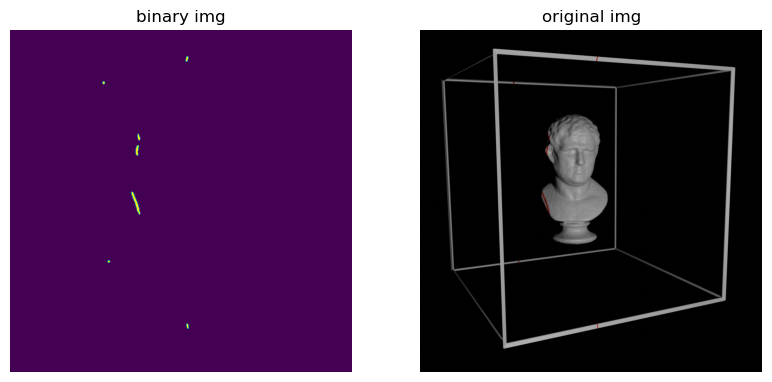

image: 1


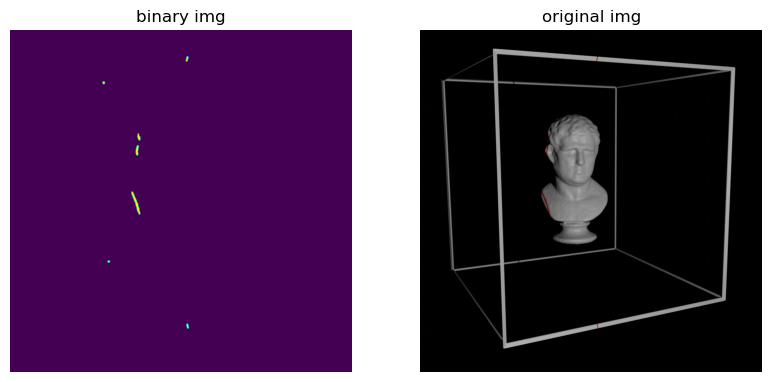

image: 2


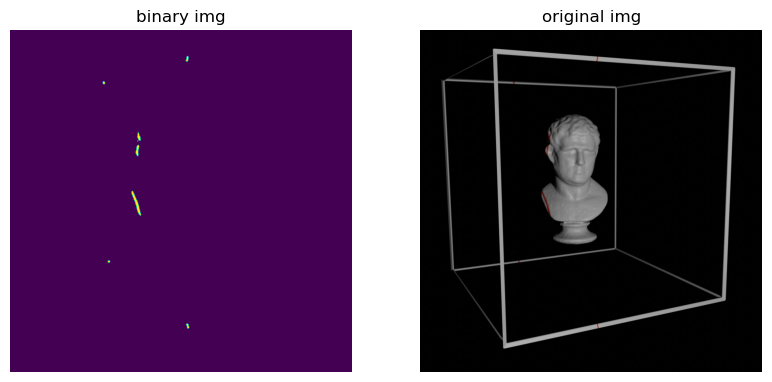

image: 3


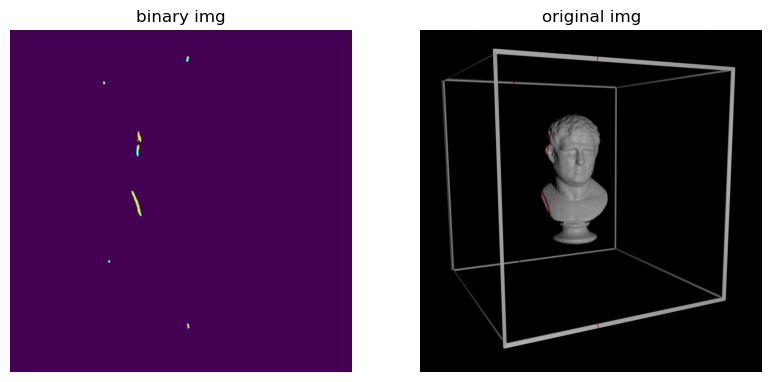

image: 4


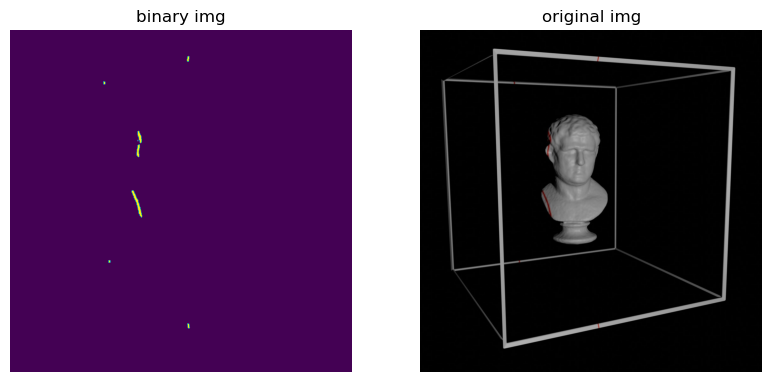

image: 5


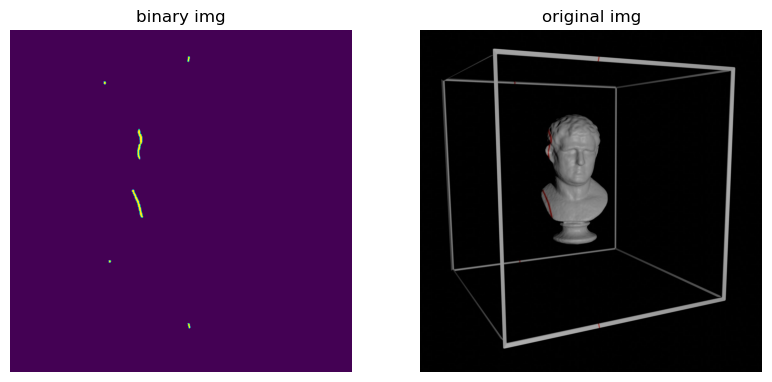

image: 6


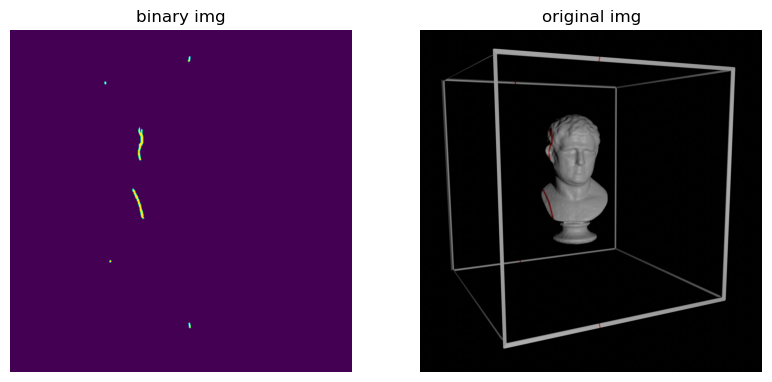

image: 7


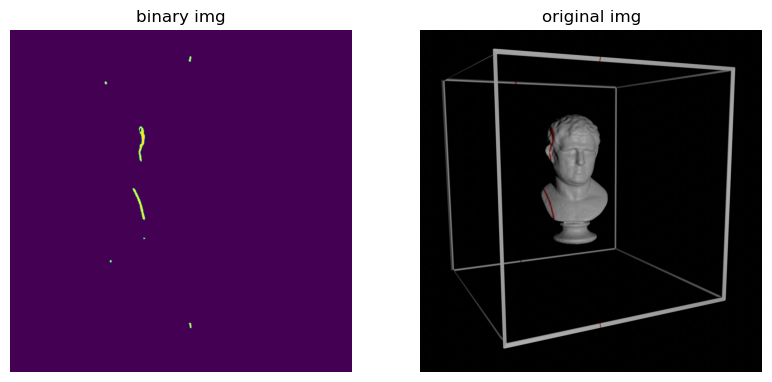

image: 8


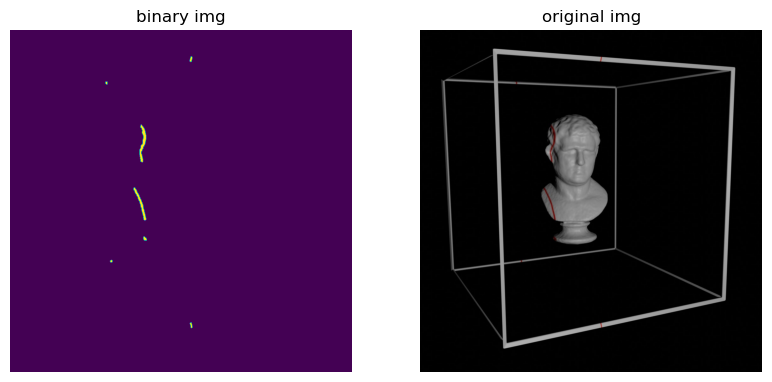

image: 9


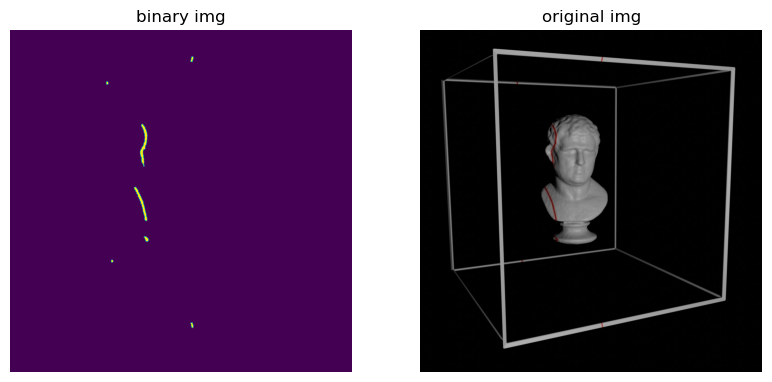

image: 10


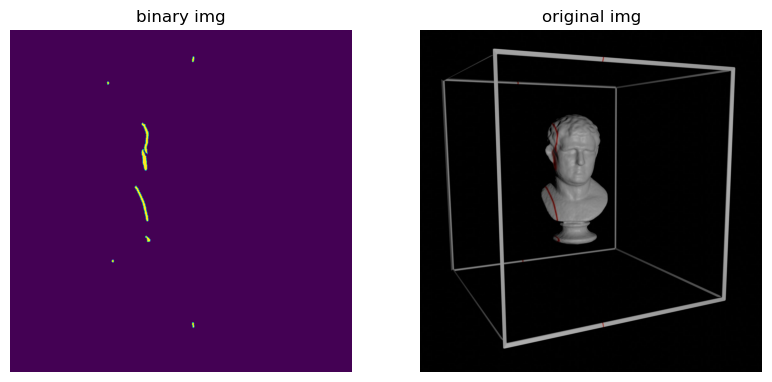

image: 11


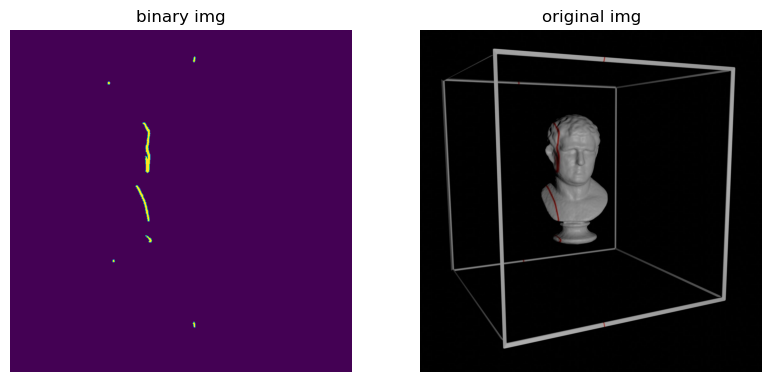

image: 12


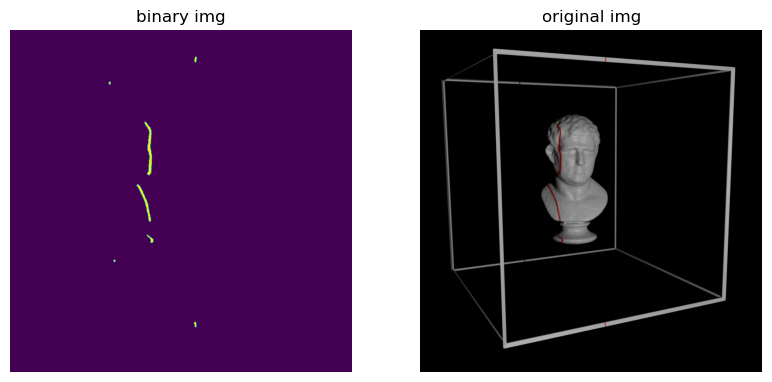

image: 13


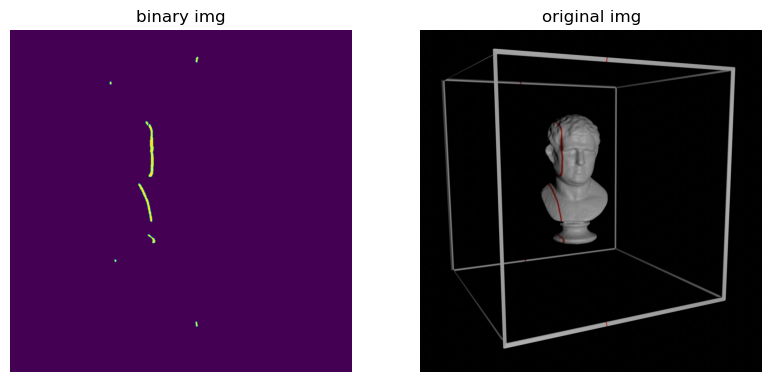

image: 14


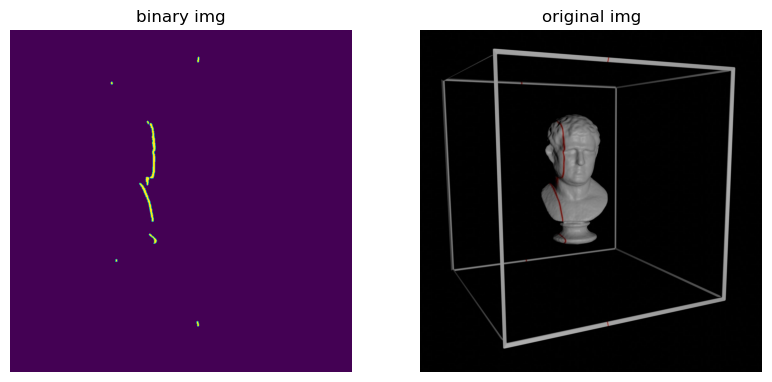

image: 15


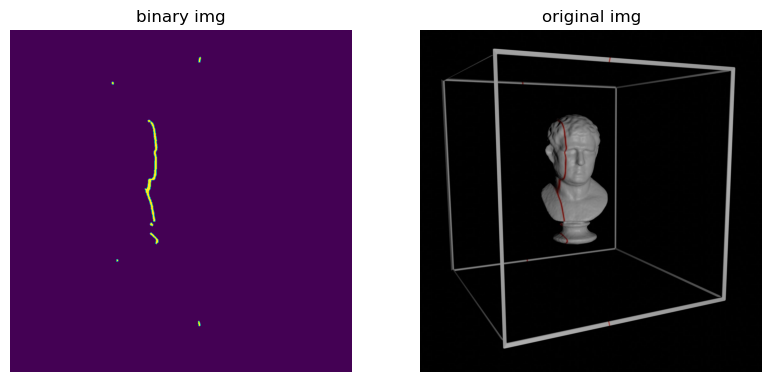

image: 16


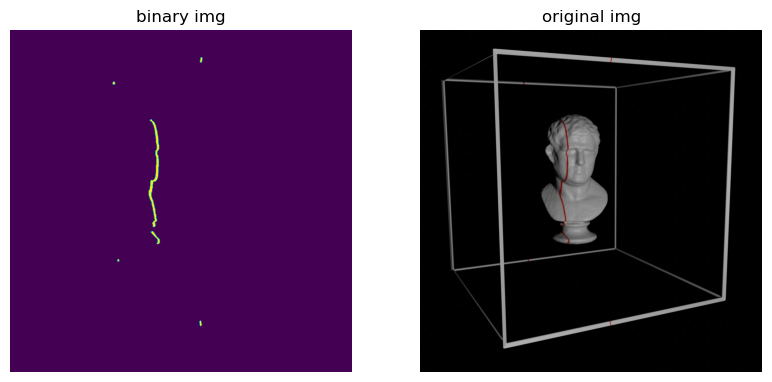

image: 17


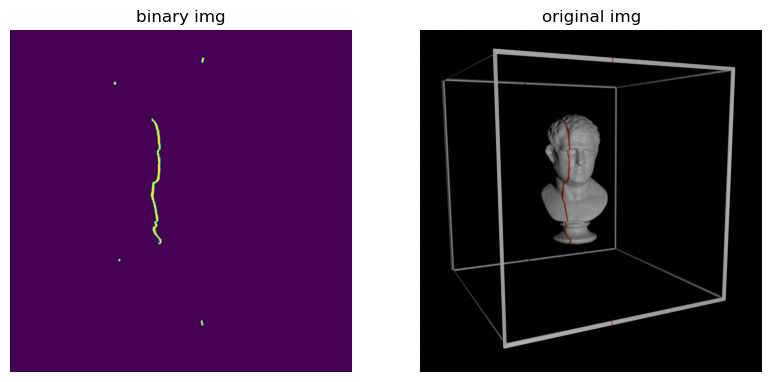

image: 18


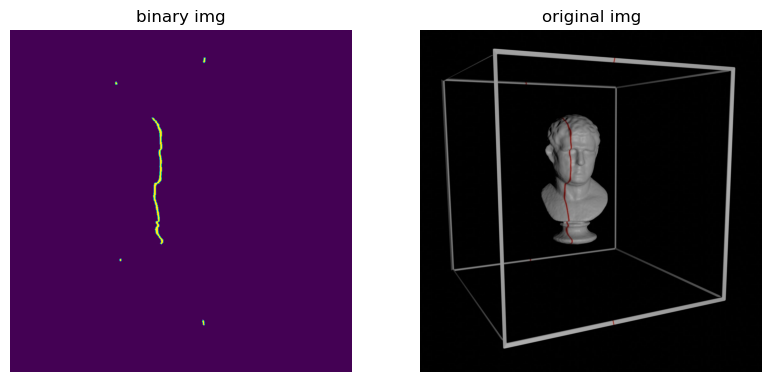

image: 19


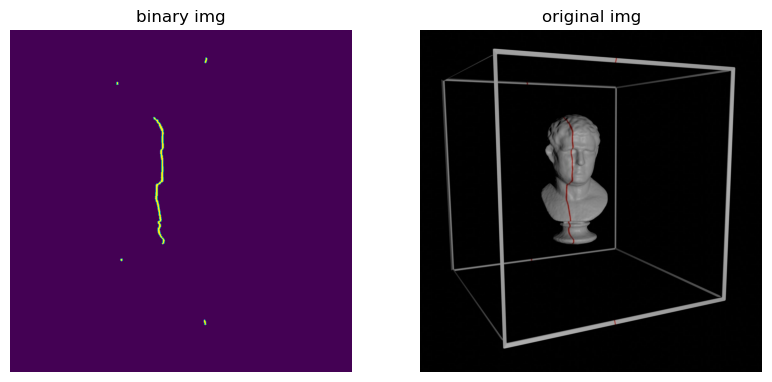

image: 20


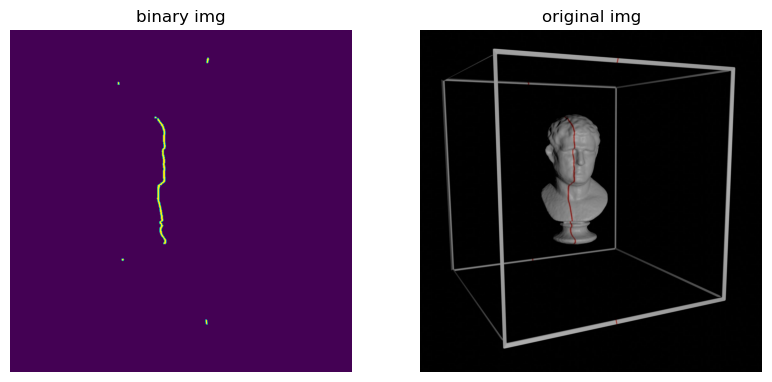

image: 21


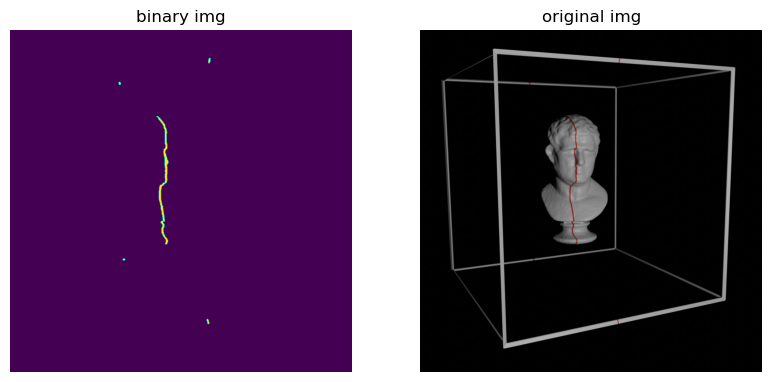

image: 22


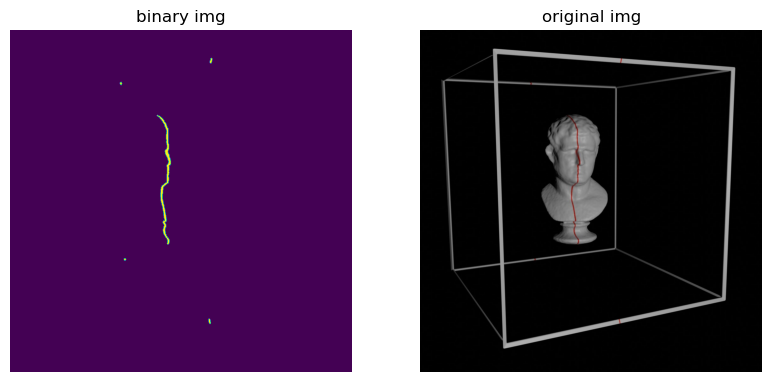

image: 23


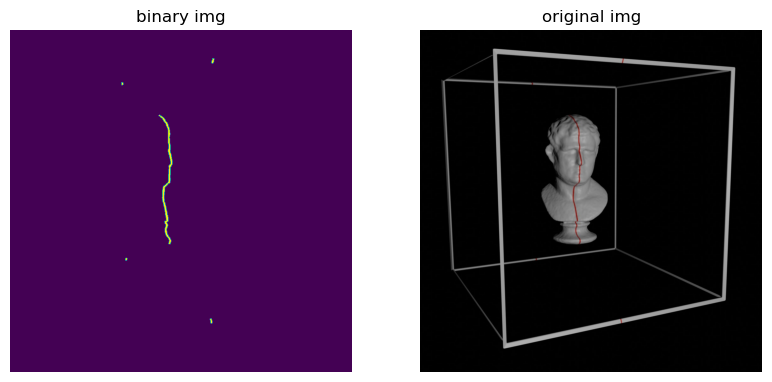

image: 24


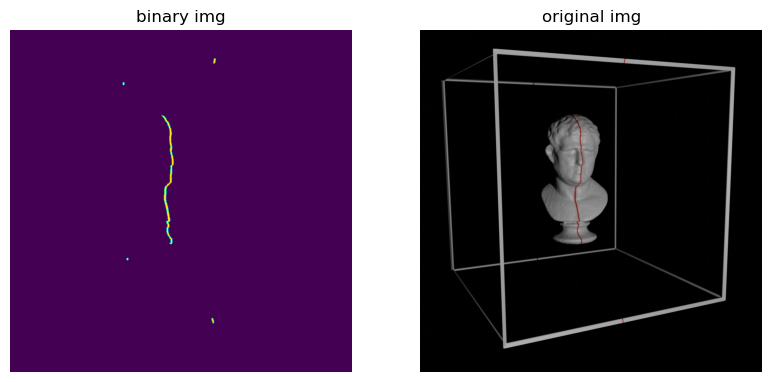

image: 25


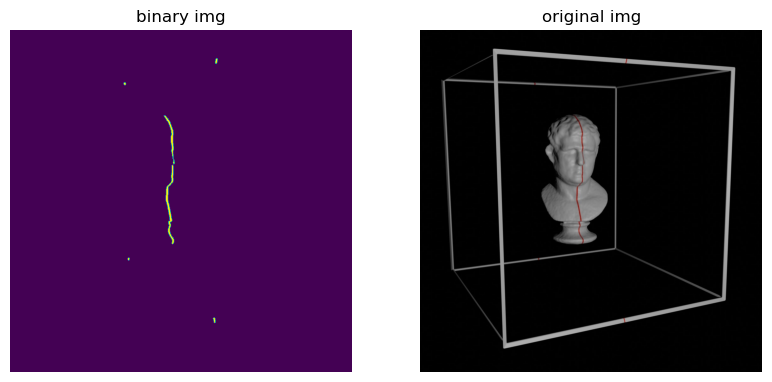

image: 26


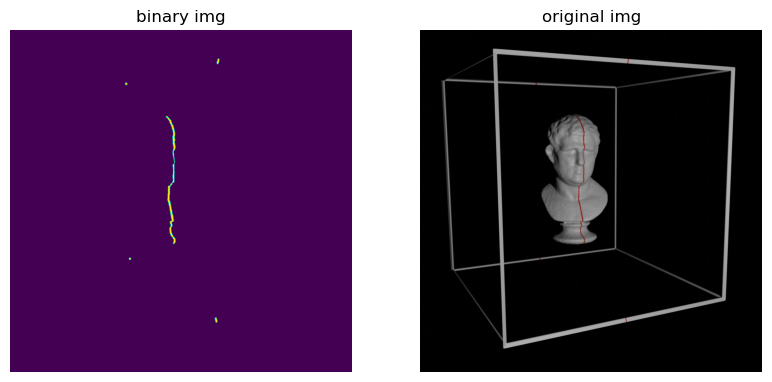

image: 27


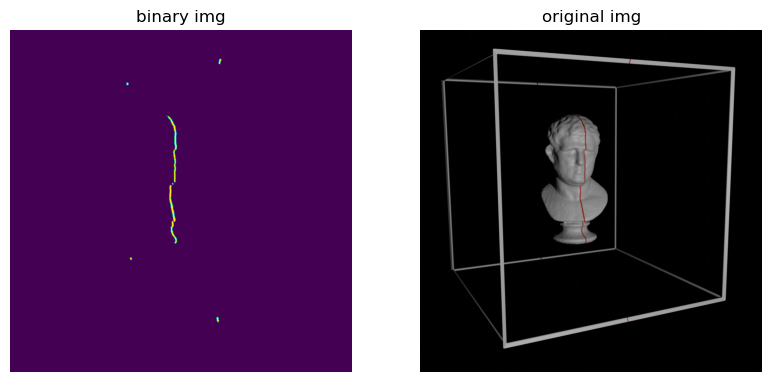

image: 28


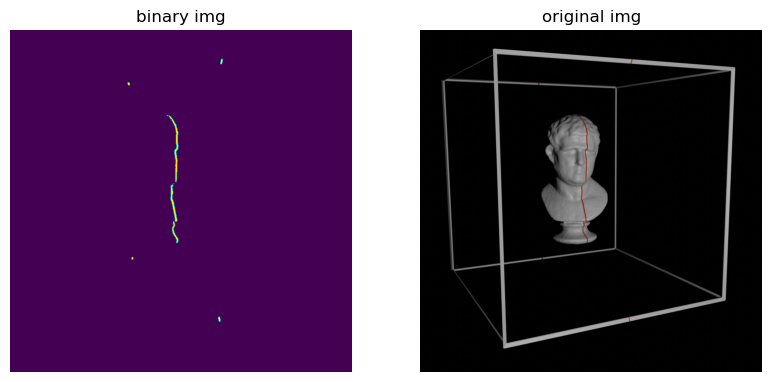

image: 29


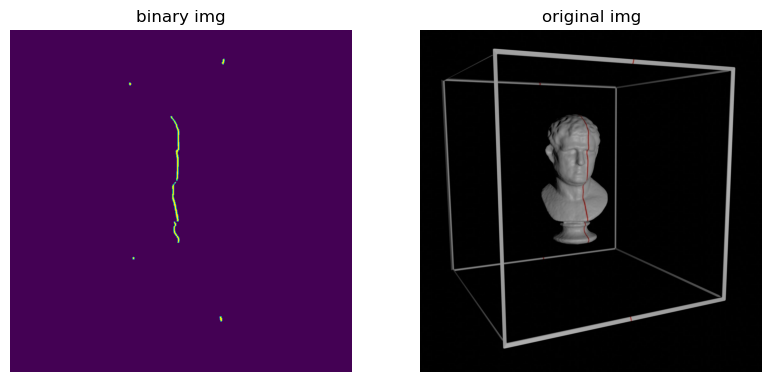

image: 30


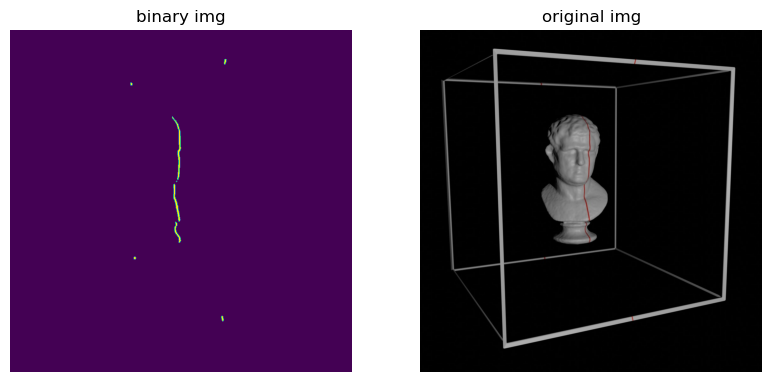

image: 31


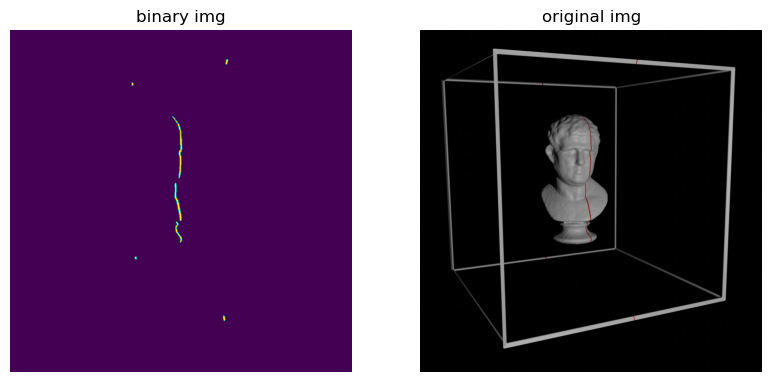

image: 32


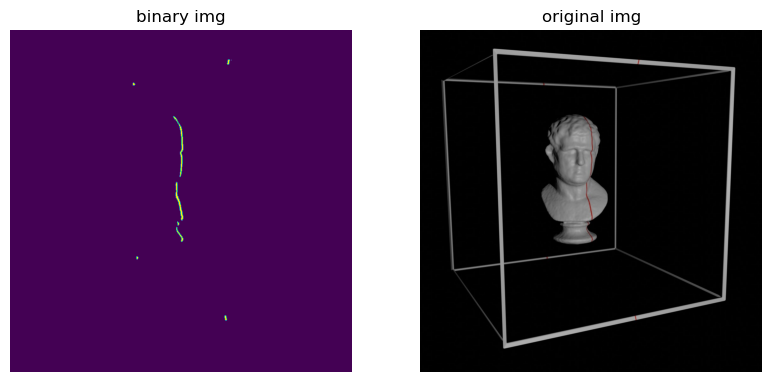

image: 33


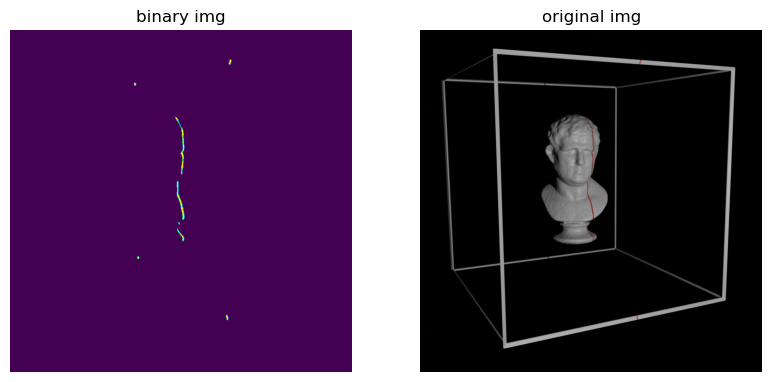

image: 34


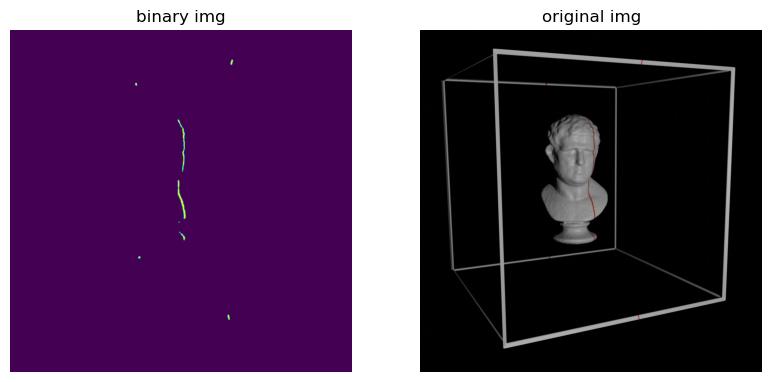

image: 35


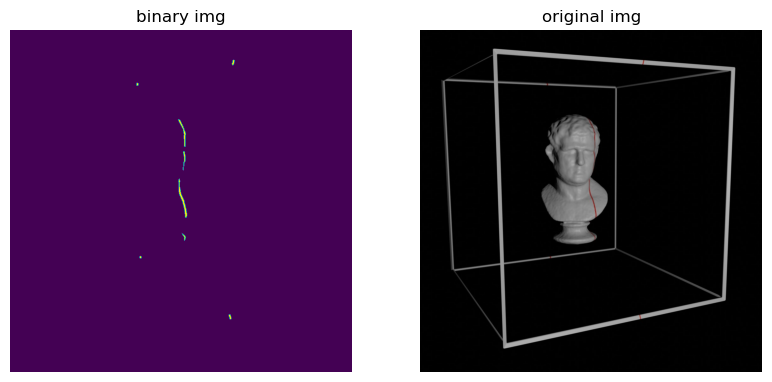

image: 36


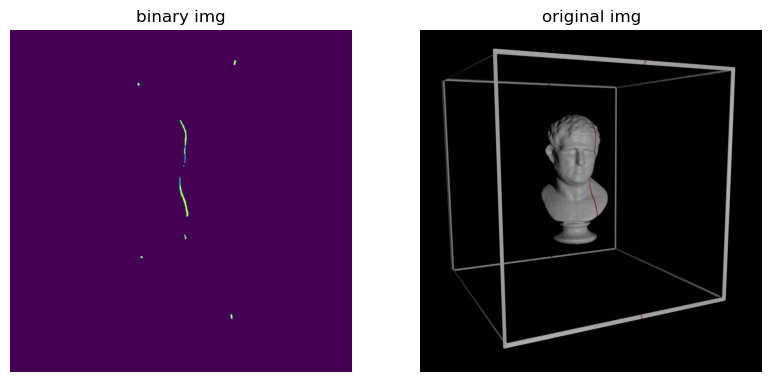

image: 37


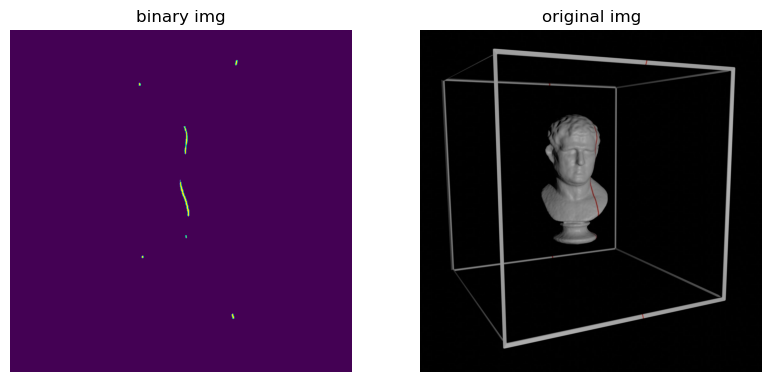

image: 38


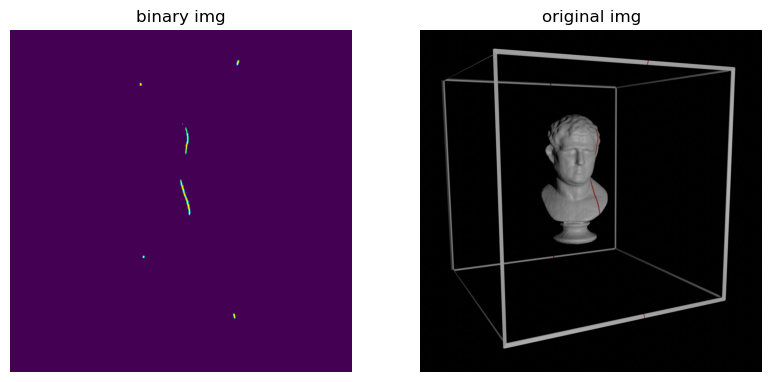

image: 39


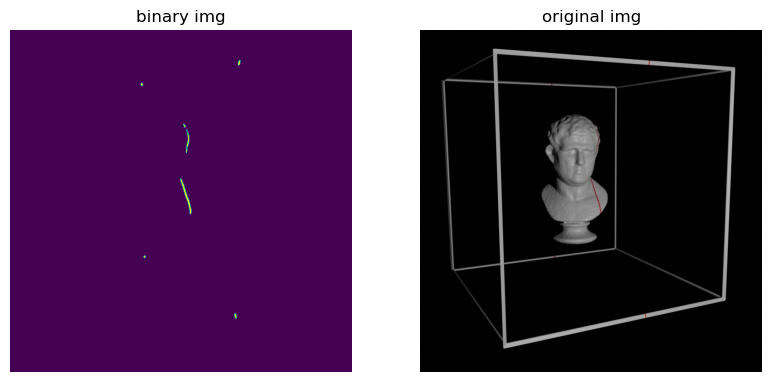

image: 40


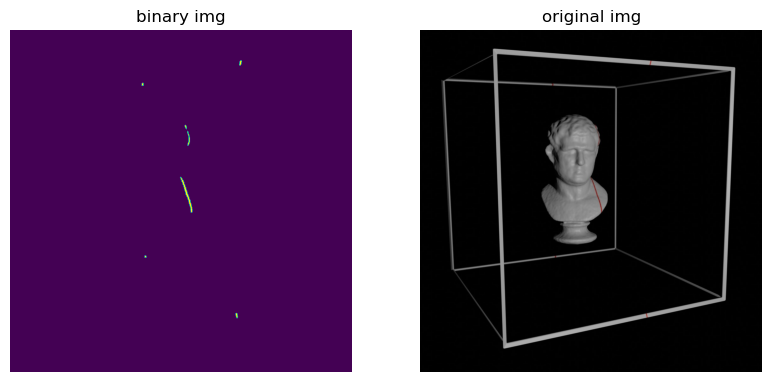

image: 41


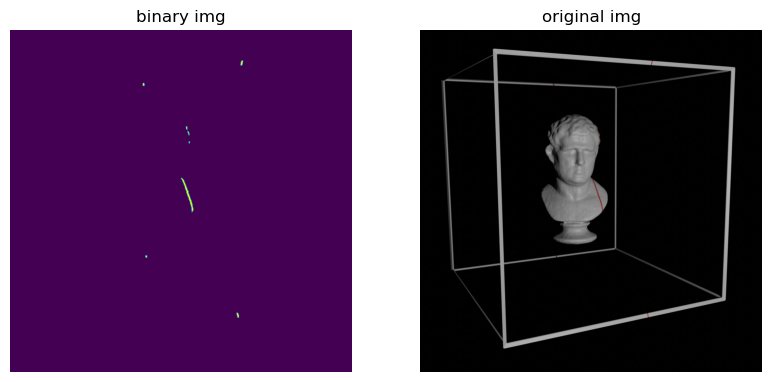

image: 42


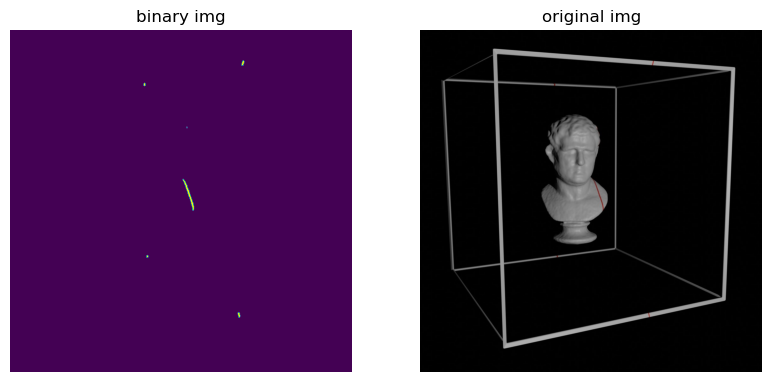

image: 43


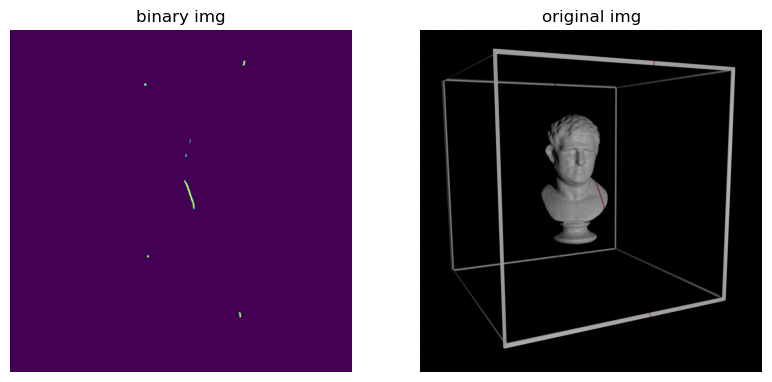

image: 44


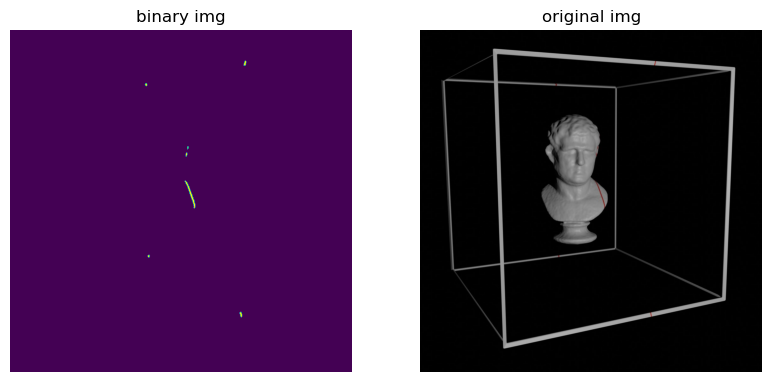

image: 45


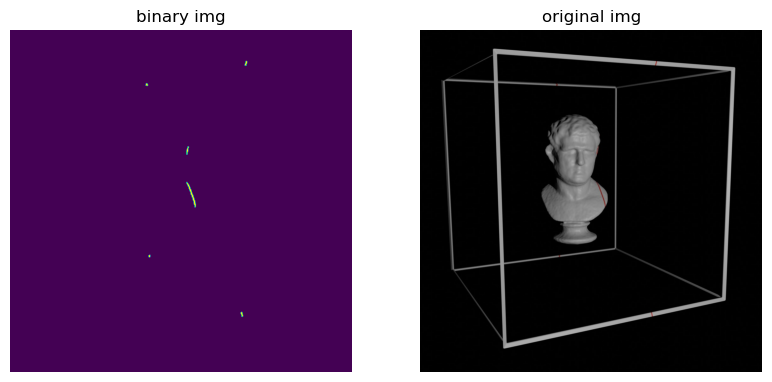

image: 46


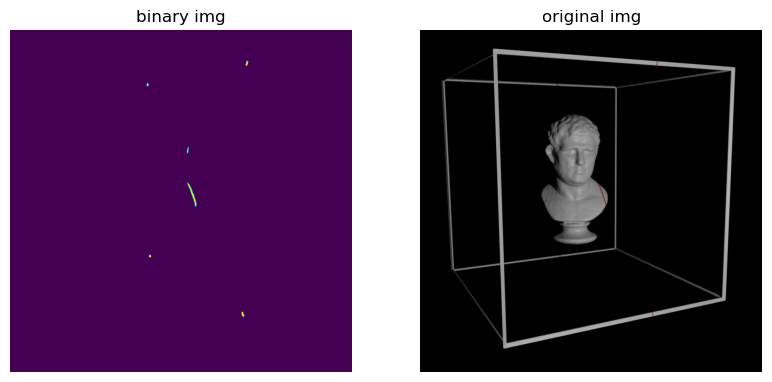

image: 47


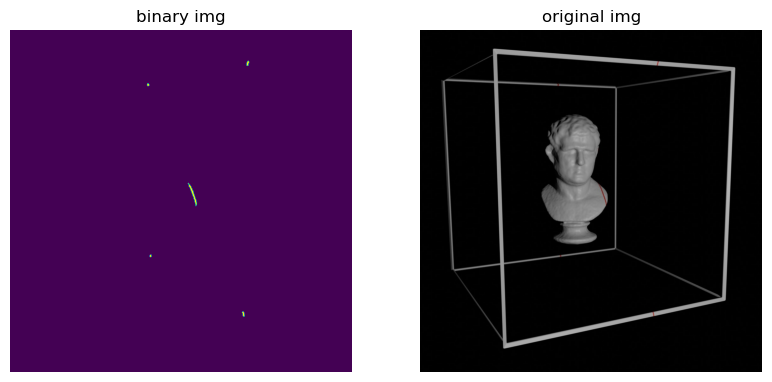

image: 48


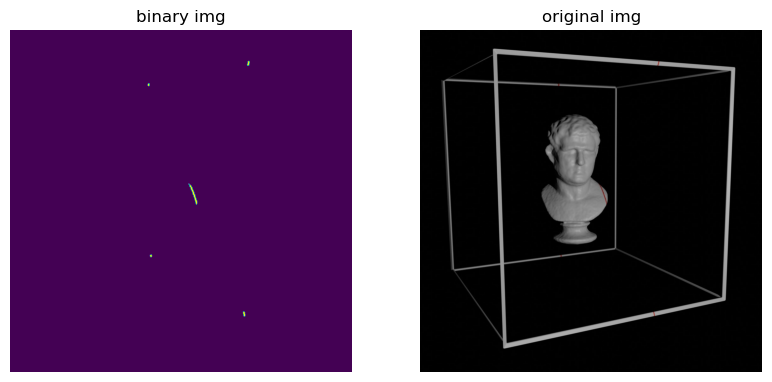

image: 49


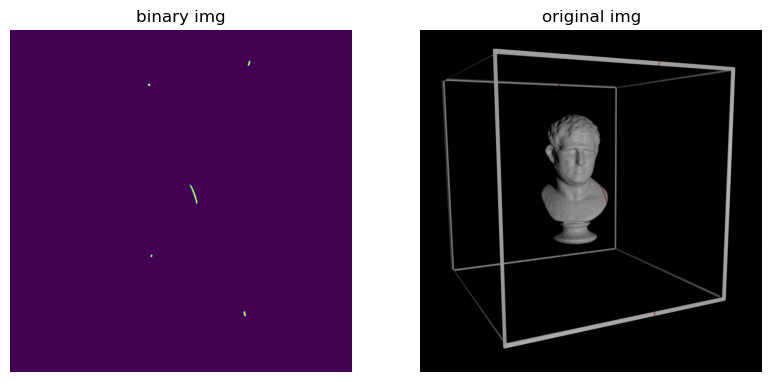

image: 50


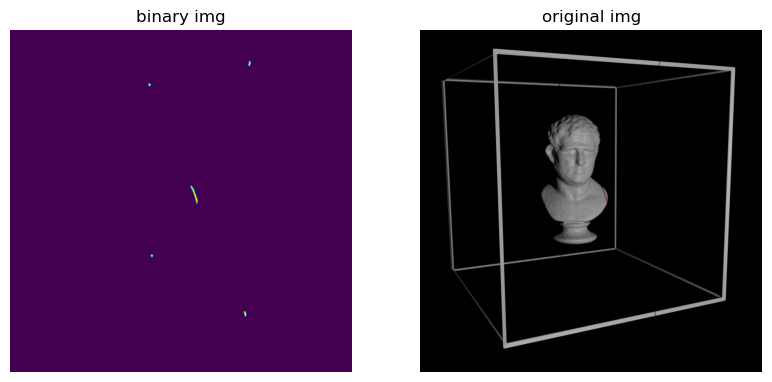

image: 51


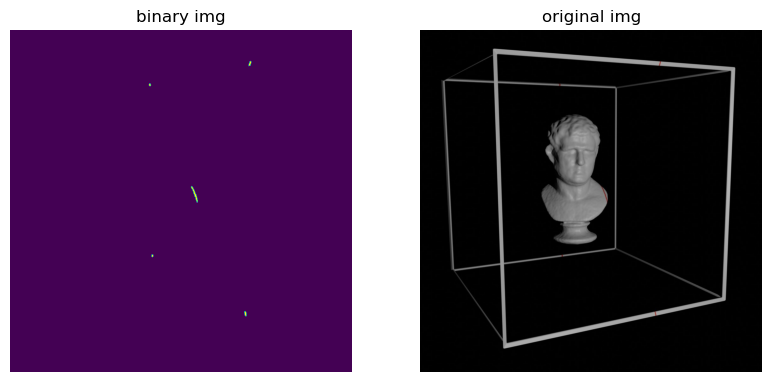

image: 52


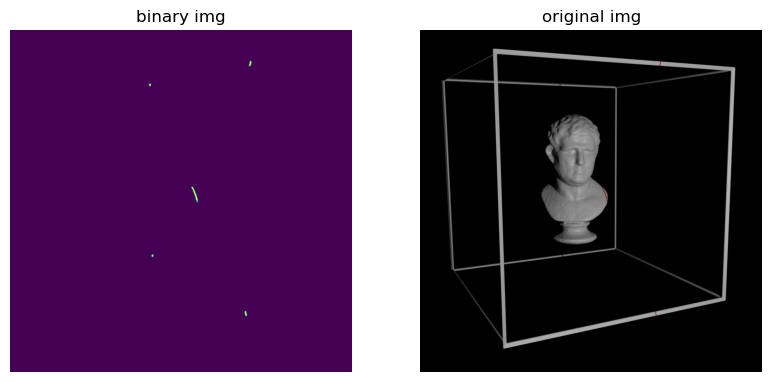

image: 53


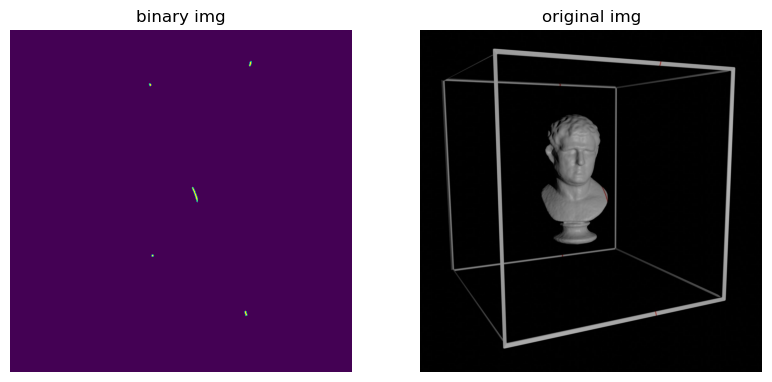

image: 54


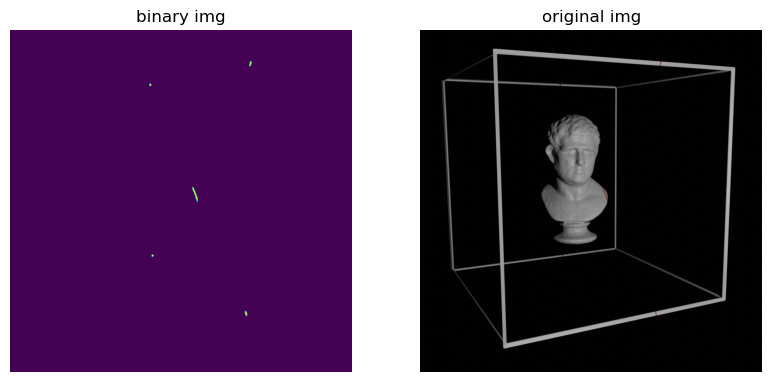

In [5]:
# plotting binary images vs original images
for x in range(55):
    fig = plt.figure(figsize=(15, 5))
    
    print('image:', x)
    fig.add_subplot(131)
    plt.title('binary img')
    plt.imshow(binary_image_list[x])
    plt.axis('off')
    
    fig.add_subplot(132)
    plt.title('original img')
    plt.imshow(images_list[x])
    plt.axis('off')
    
    plt.show()

In [6]:
# function to find the first occurence of a white pixel in a given row of a binary image,
# the index of the pixel is the same as the x coordinate
def find_x_coordinate(row_list):
    for idx, col in enumerate(row_list):
        if col: # when red pixel is found
            return idx
        
    return None

In [7]:
# function to find the 4 points of the red shadow on the wireframe, we will
# use them to perform homography
def find_source_pts(binary_image):
    
    red_px = np.sum(binary_image, axis=1) # row list
    red_px = red_px > 0
    
    # find y coodinates of the red shadow pattern
    # the first 4, and last 4 elements on "y" correspond to the red shadow cast on the wireframe
    last_value = 0
    y = []
    
    for idx in range(red_px.shape[0]):
        if red_px[idx] != last_value:        
            last_value = red_px[idx]
            y.append(idx)
    
    # find x coordinates of the red shadow pattern
    x_1 = find_x_coordinate(binary_image[y[1] - 1])  # upper-right corner of wireframe
    x_2 = find_x_coordinate(binary_image[y[3] - 1])  # upper-left
    x_3 = find_x_coordinate(binary_image[y[-4]])     # lower-left 
    x_4 = find_x_coordinate(binary_image[y[-2]])     # lower-right
    
    # source points of the wireframe to use for homography
    source_pts = np.array([[x_1, y[1]],
                           [x_2, y[3]],
                           [x_3, y[-4] - 1],
                           [x_4, y[-2] - 1]])
    
    return source_pts

In [8]:
# list of source points in the wireframe
source_pts_list = [find_source_pts(img) for img in binary_image_list]
source_pts_list

[array([[558, 100],
        [293, 171],
        [312, 726],
        [558, 926]]),
 array([[557, 100],
        [294, 171],
        [312, 726],
        [558, 926]]),
 array([[557, 100],
        [294, 171],
        [312, 726],
        [559, 926]]),
 array([[557, 100],
        [296, 172],
        [311, 726],
        [560, 926]]),
 array([[560, 100],
        [296, 172],
        [312, 726],
        [560, 926]]),
 array([[562, 101],
        [298, 172],
        [312, 726],
        [561, 925]]),
 array([[564, 101],
        [300, 172],
        [314, 726],
        [565, 923]]),
 array([[565, 100],
        [302, 172],
        [319, 725],
        [565, 924]]),
 array([[570, 101],
        [304, 172],
        [320, 725],
        [571, 922]]),
 array([[573, 101],
        [305, 172],
        [320, 725],
        [571, 923]]),
 array([[575, 101],
        [307, 172],
        [325, 724],
        [576, 922]]),
 array([[580, 102],
        [309, 172],
        [326, 724],
        [580, 920]]),
 array([[584, 10

In [9]:
# function to perform homography transformation to an image
def perform_homography(source, destination, image):
    
    h_matrix, _ = cv.findHomography(source, destination)
    result = cv.warpPerspective(image, h_matrix, (200, 200))
    
    return result

In [10]:
# destination point
destination_pt = np.array([[200, 0],
                           [0,   0],
                           [0,   200],
                           [200, 200]])

# perform homography in all images
binary_img_homography = [perform_homography(src, destination_pt, img) for (src, img) in zip(source_pts_list, binary_image_list)]
original_img_homography = [perform_homography(src, destination_pt, img) for (src, img) in zip(source_pts_list, images_list)]

image: 0


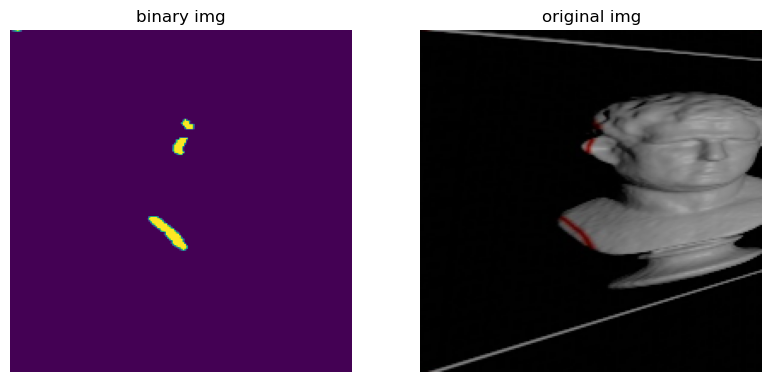

image: 1


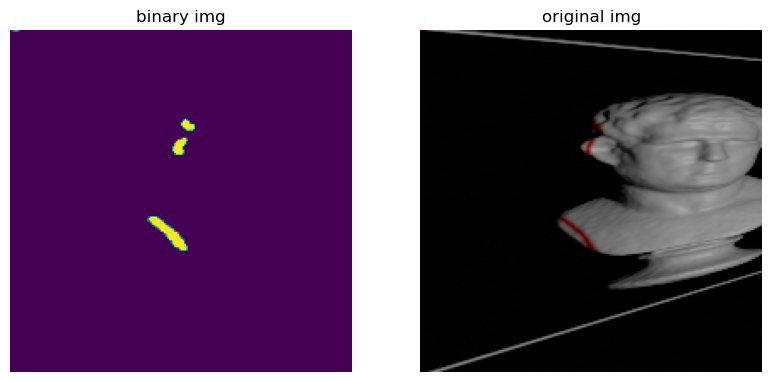

image: 2


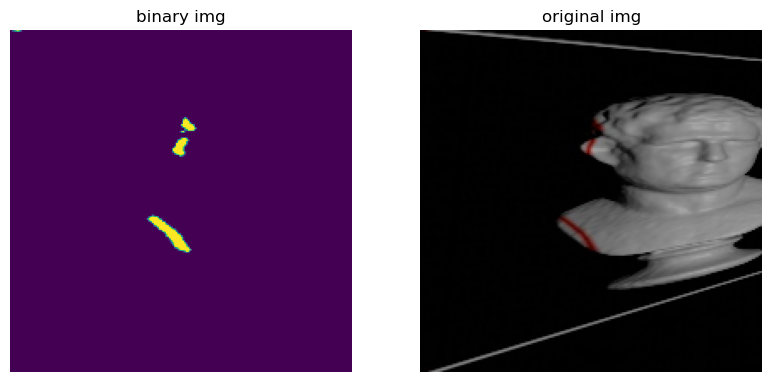

image: 3


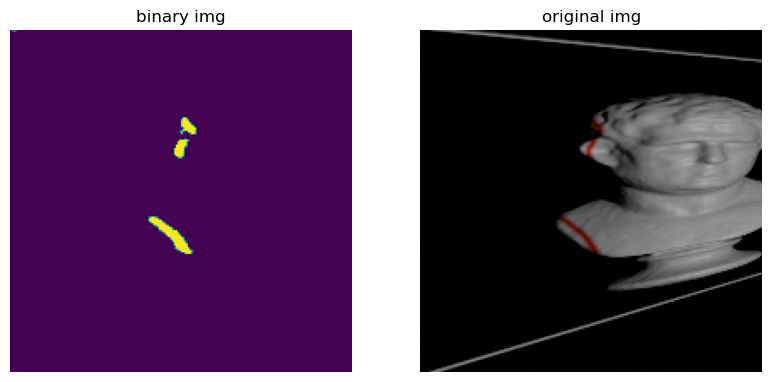

image: 4


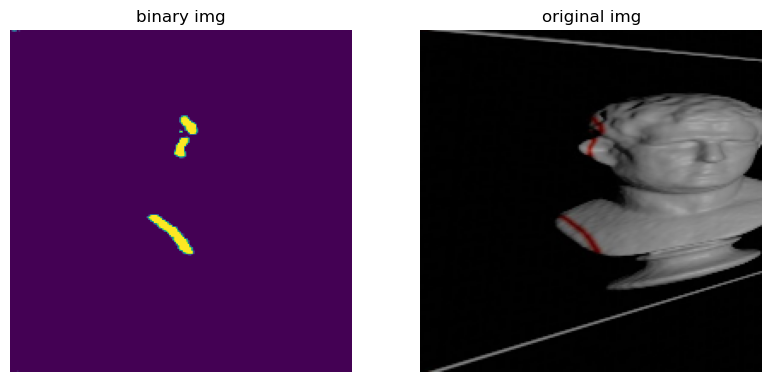

image: 5


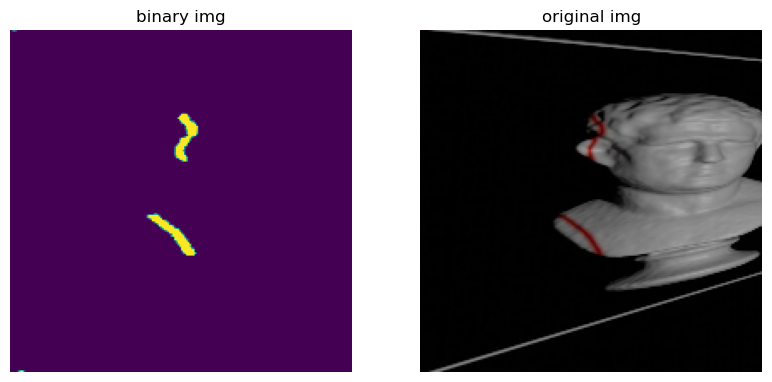

image: 6


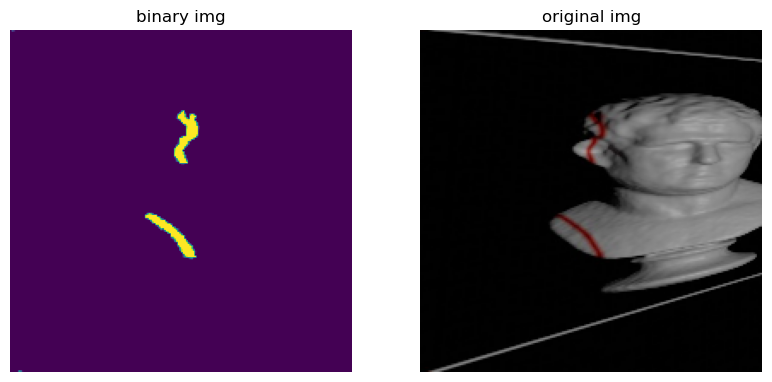

image: 7


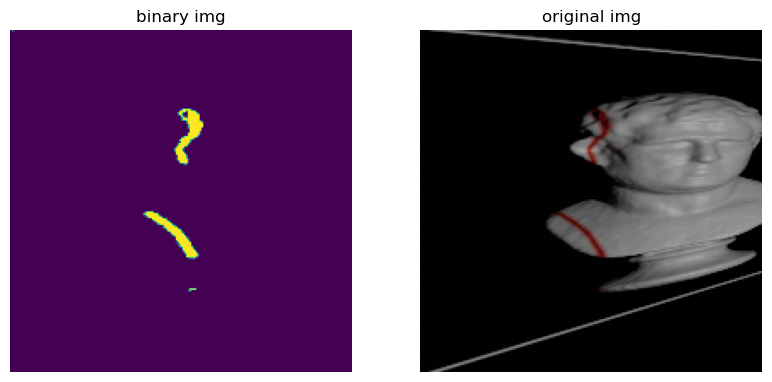

image: 8


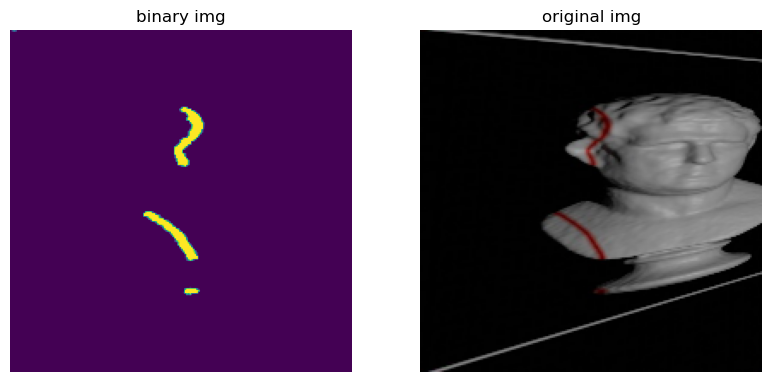

image: 9


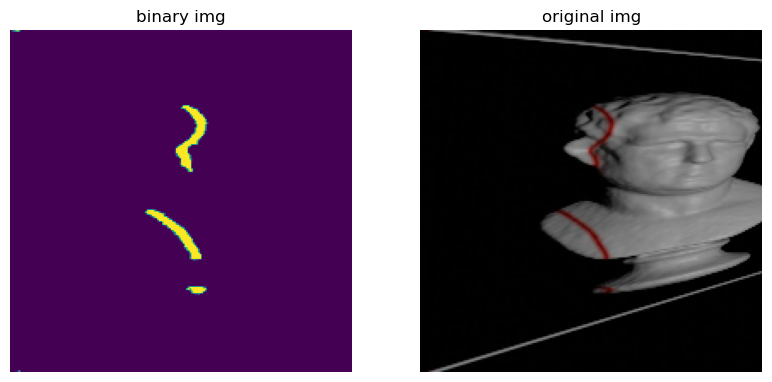

image: 10


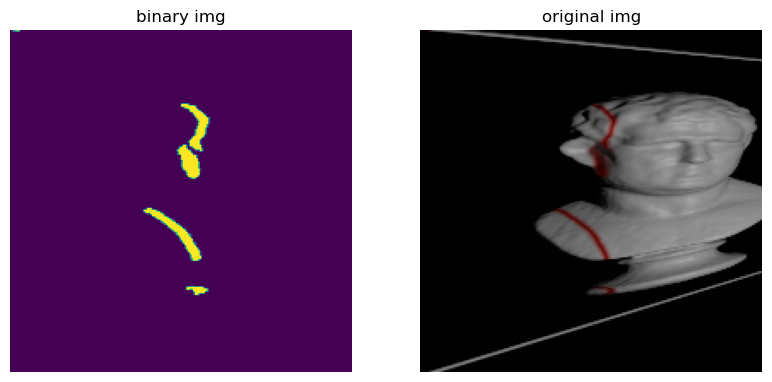

image: 11


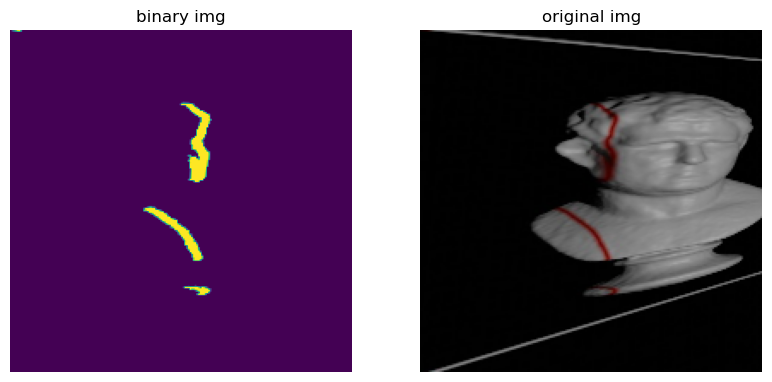

image: 12


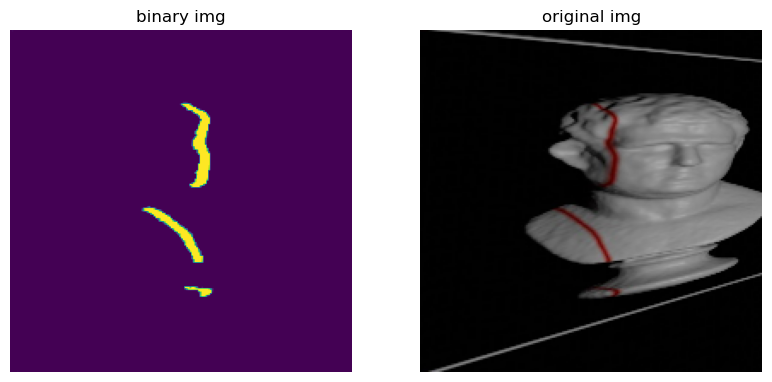

image: 13


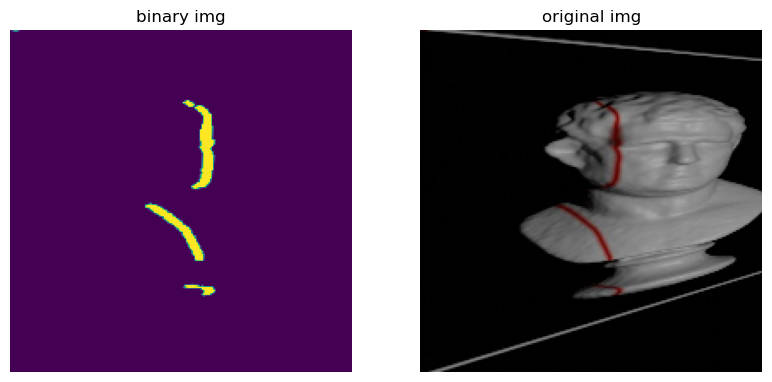

image: 14


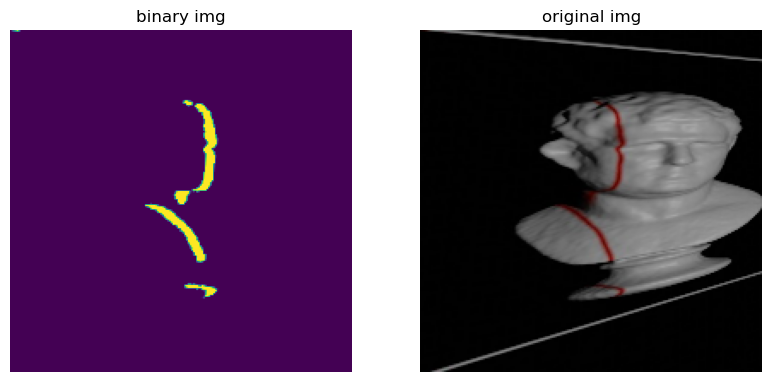

image: 15


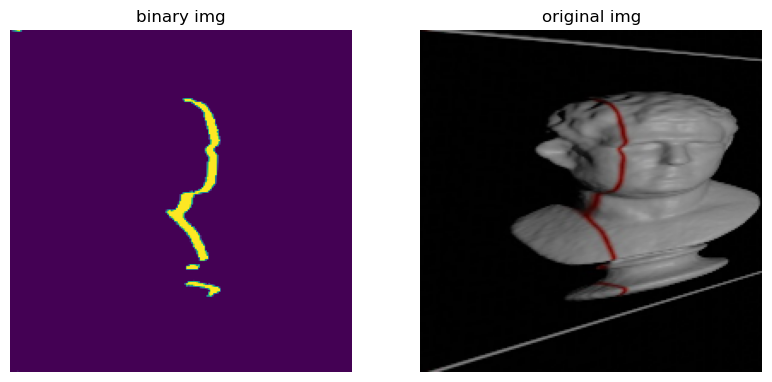

image: 16


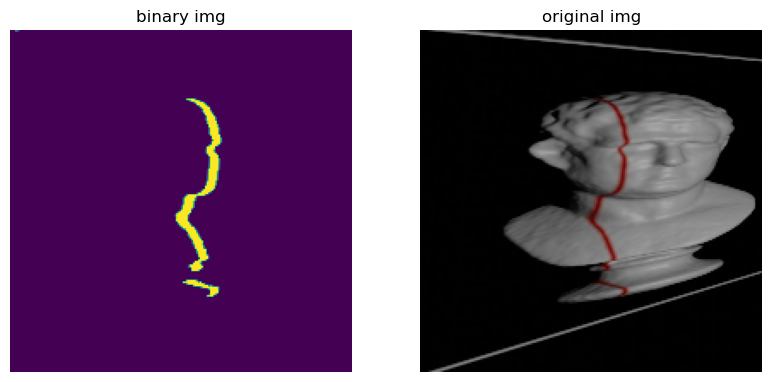

image: 17


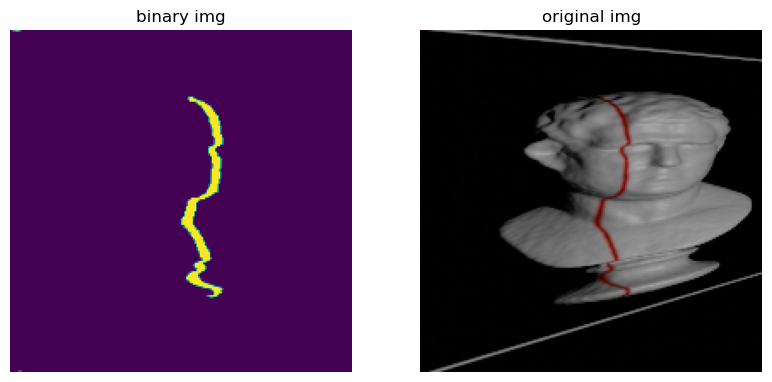

image: 18


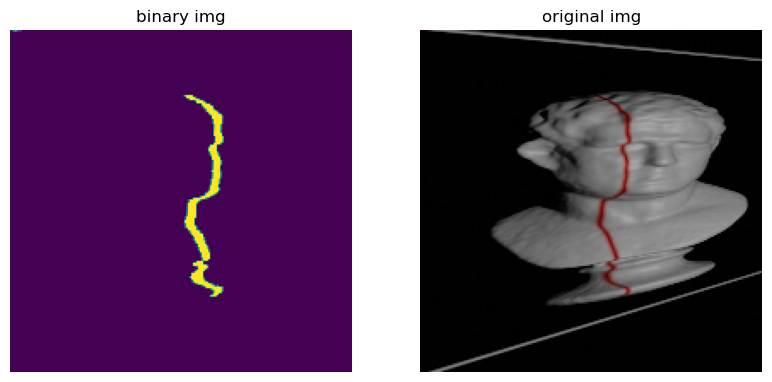

image: 19


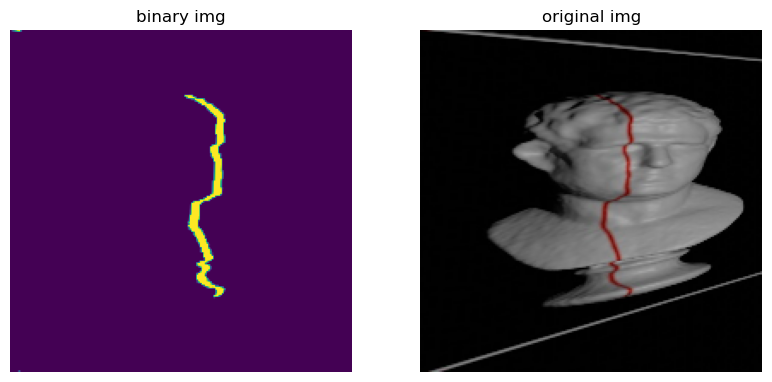

image: 20


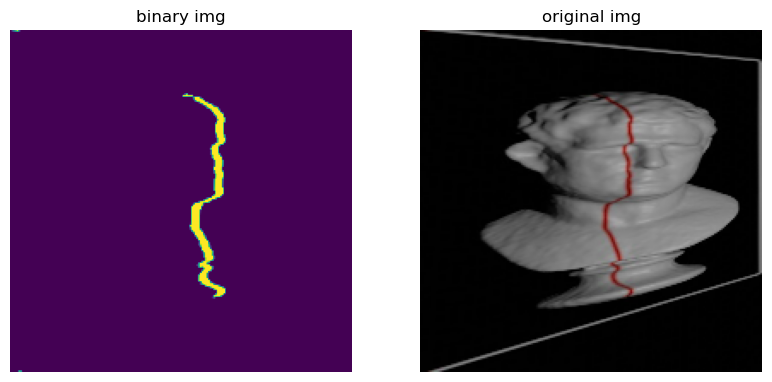

image: 21


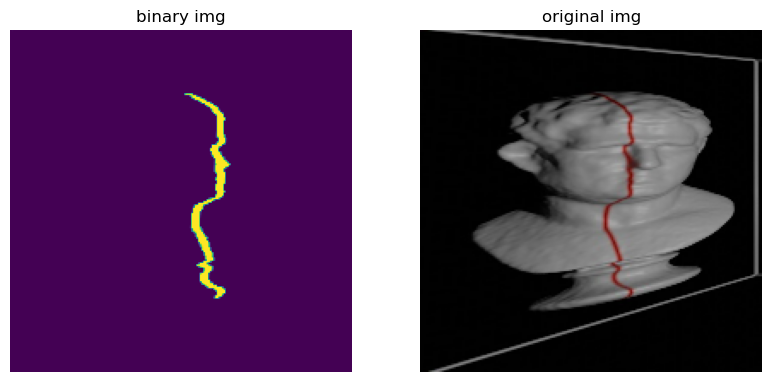

image: 22


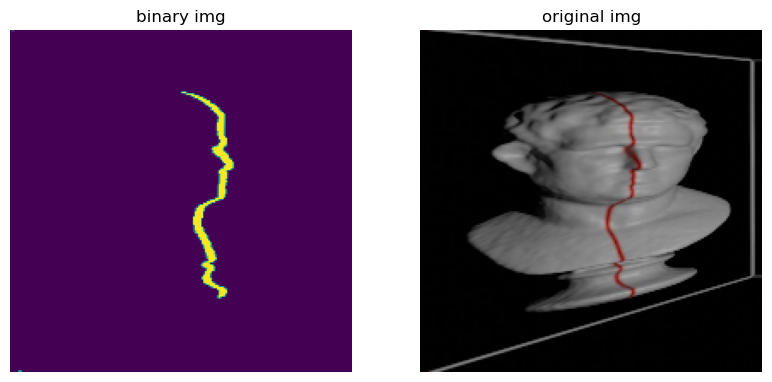

image: 23


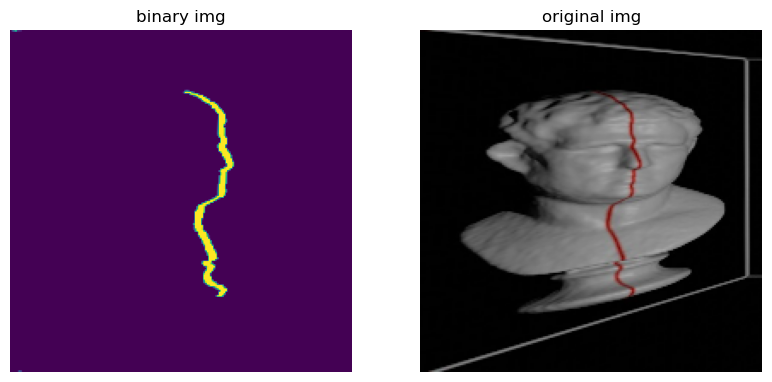

image: 24


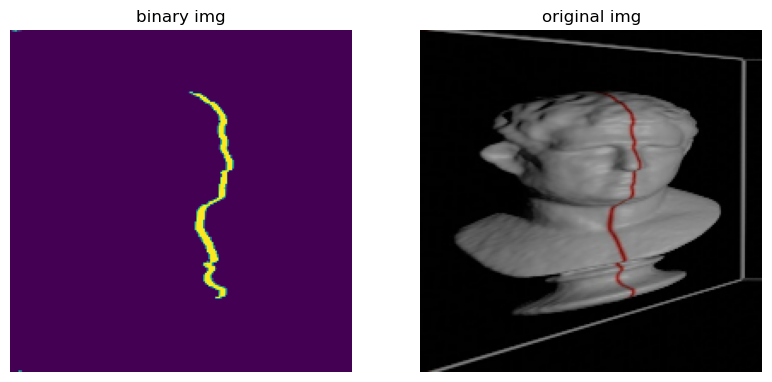

image: 25


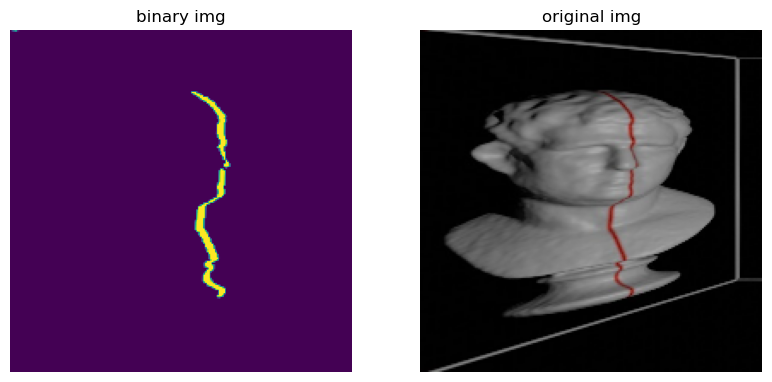

image: 26


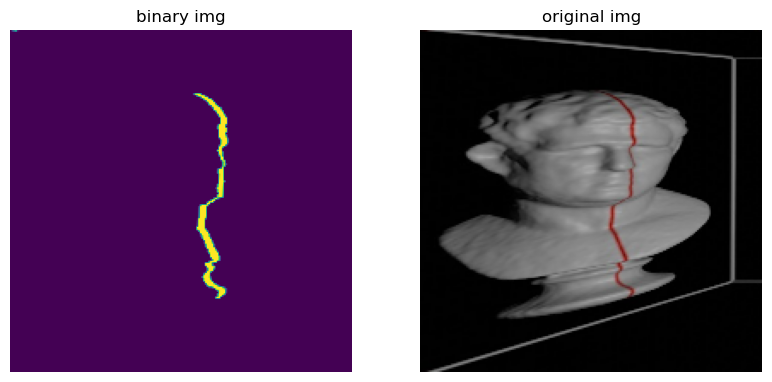

image: 27


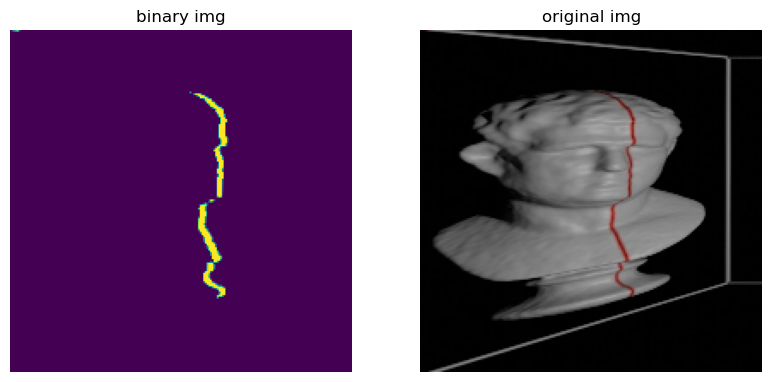

image: 28


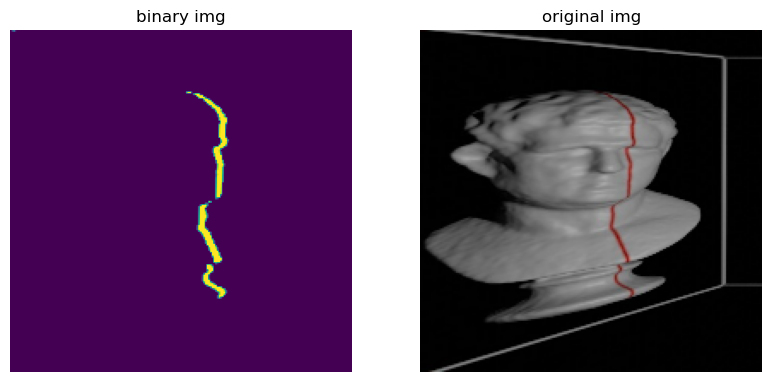

image: 29


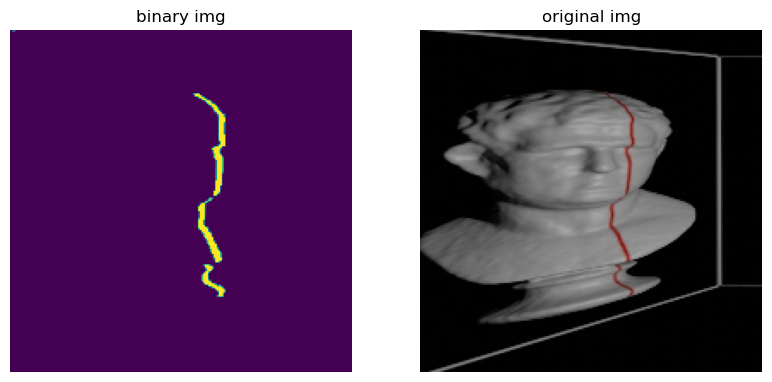

image: 30


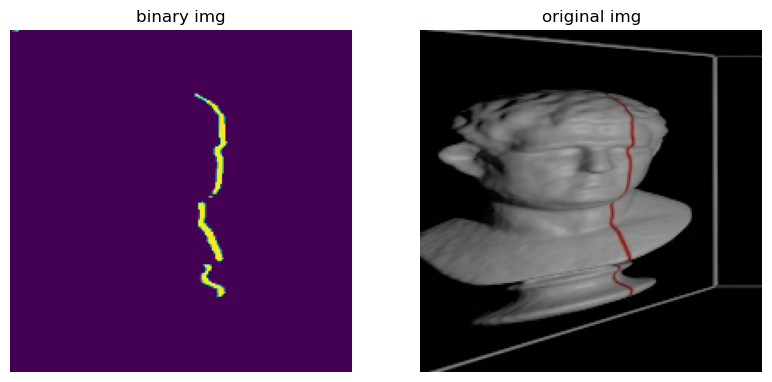

image: 31


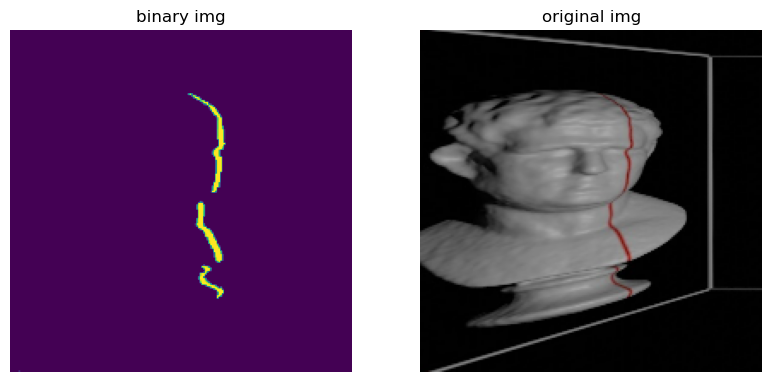

image: 32


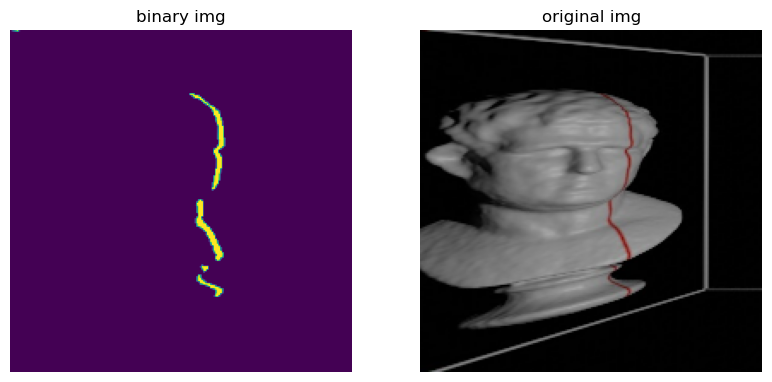

image: 33


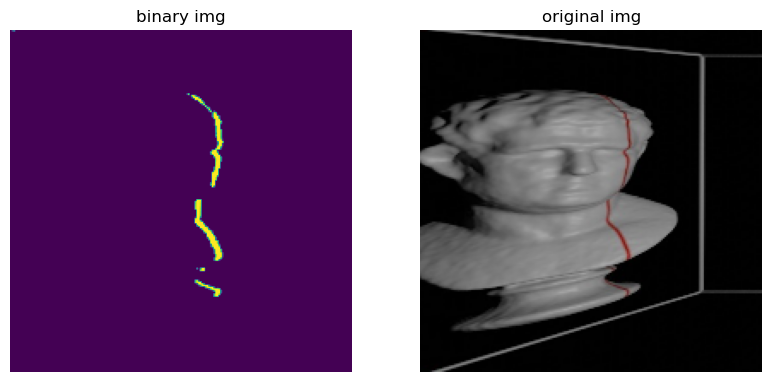

image: 34


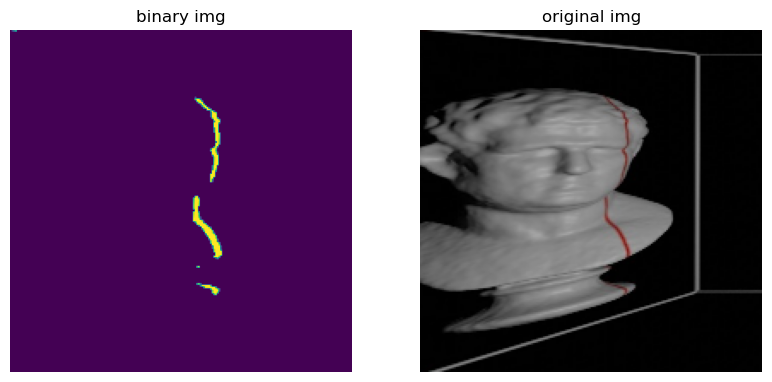

image: 35


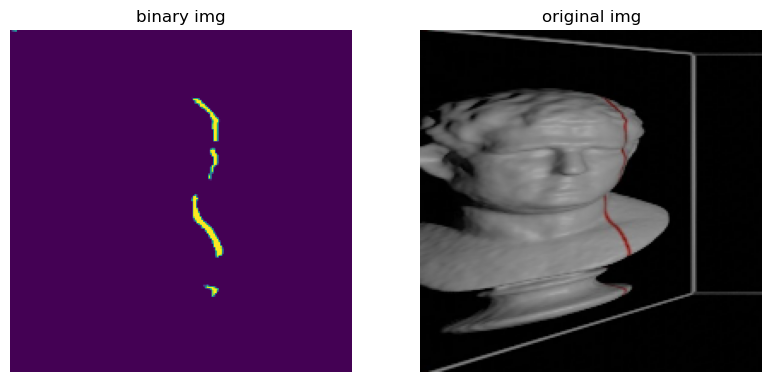

image: 36


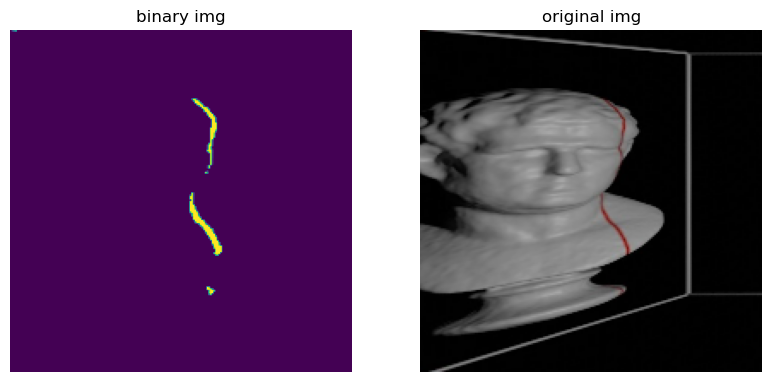

image: 37


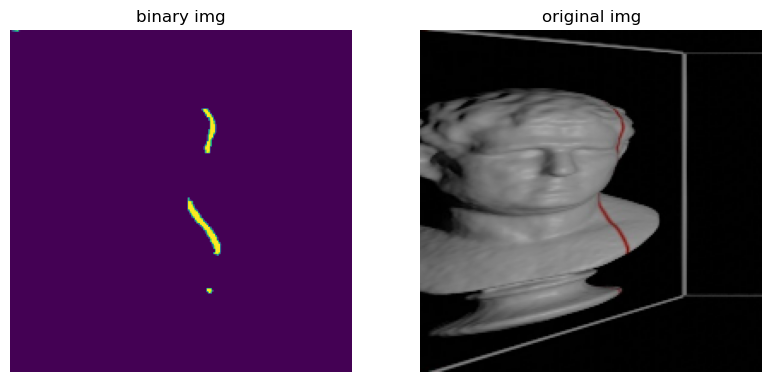

image: 38


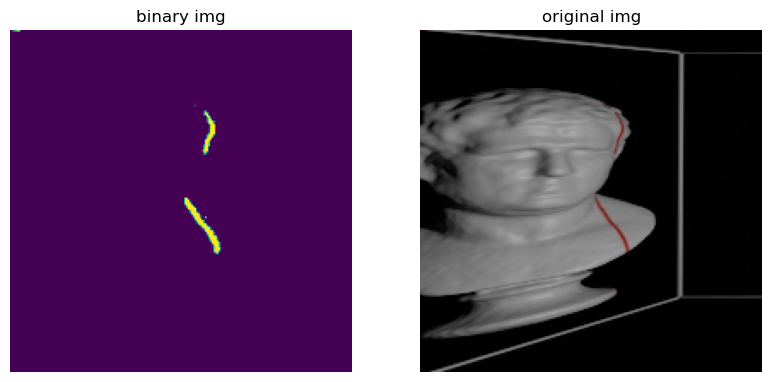

image: 39


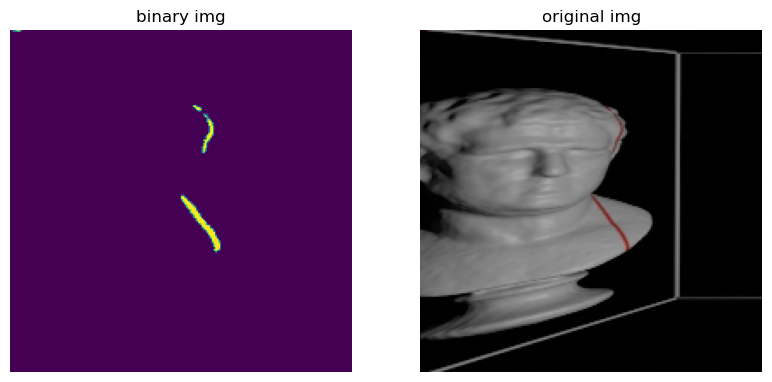

image: 40


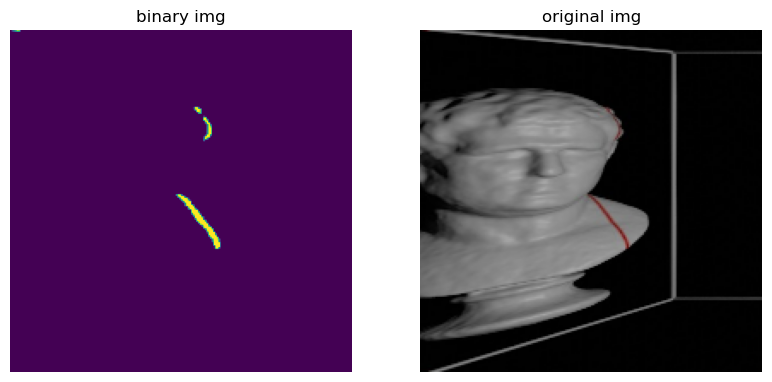

image: 41


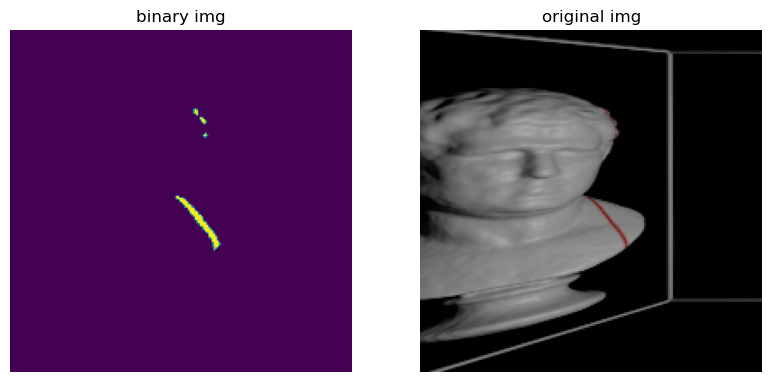

image: 42


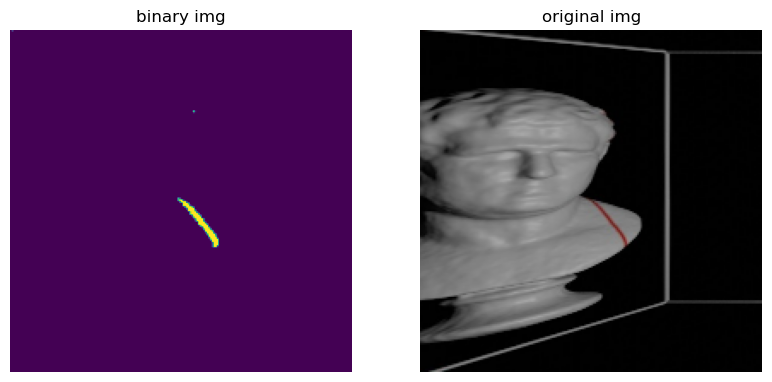

image: 43


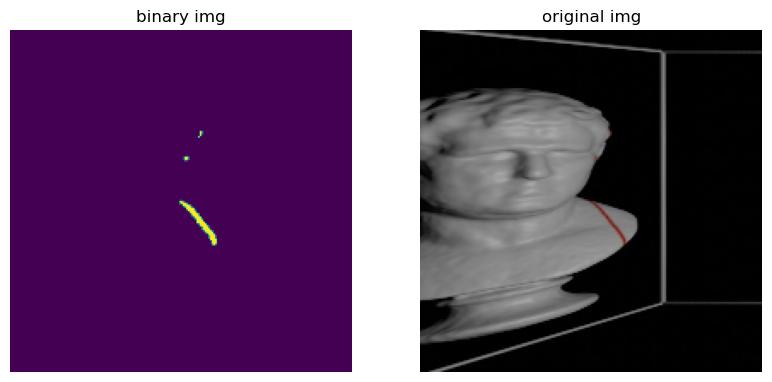

image: 44


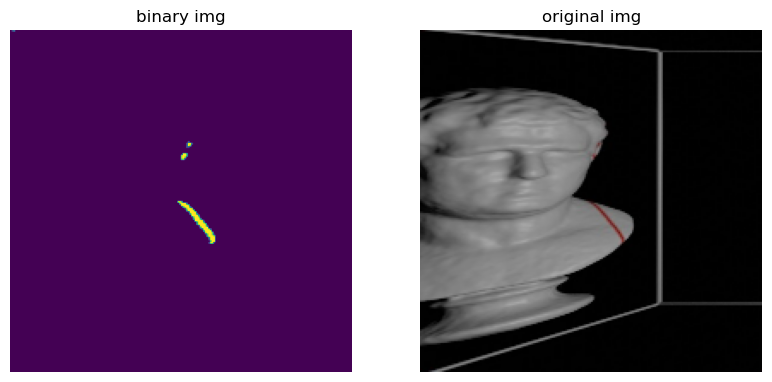

image: 45


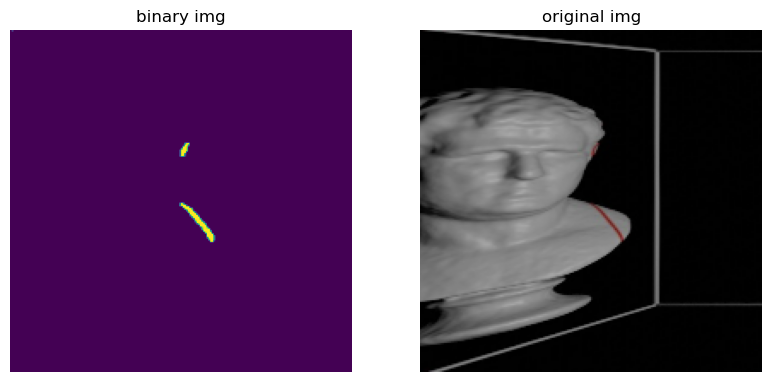

image: 46


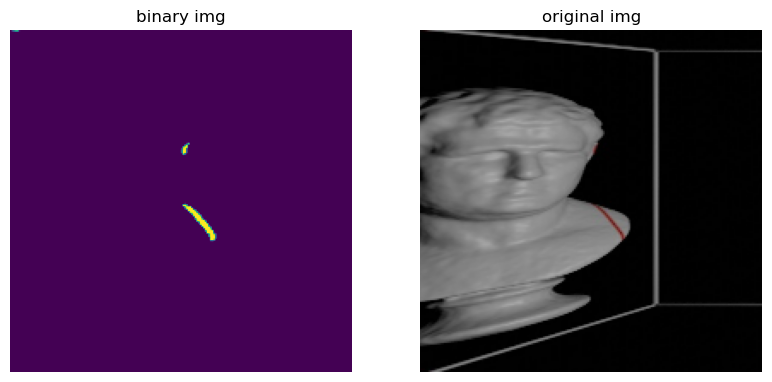

image: 47


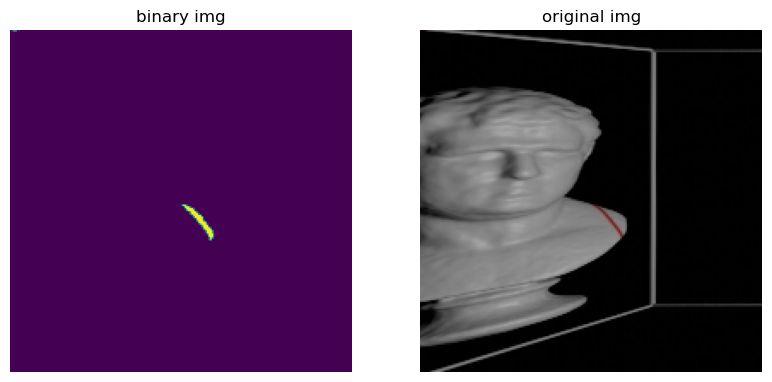

image: 48


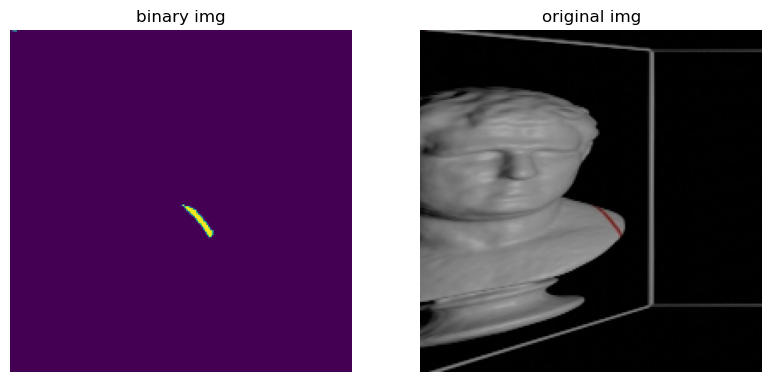

image: 49


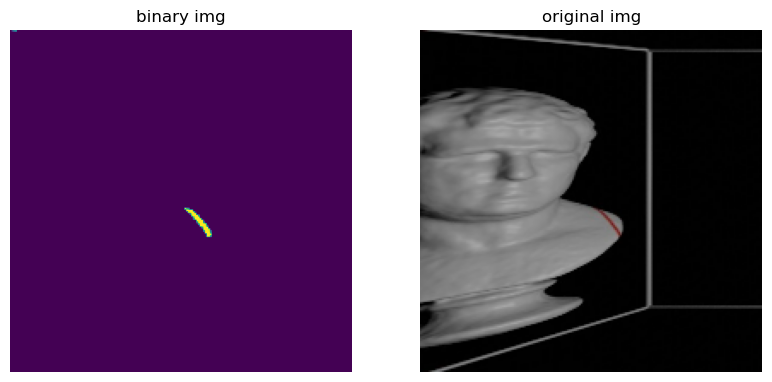

image: 50


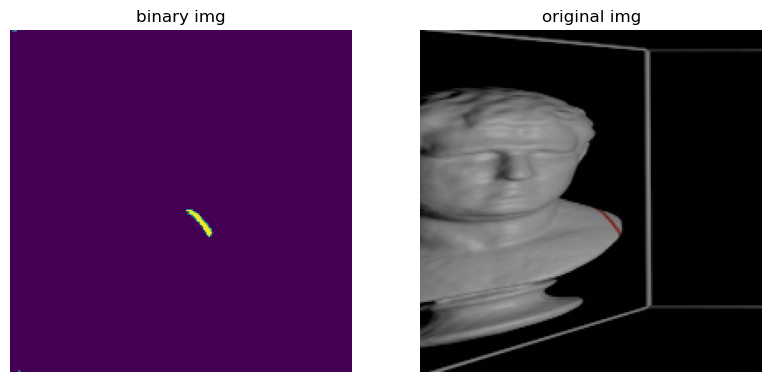

image: 51


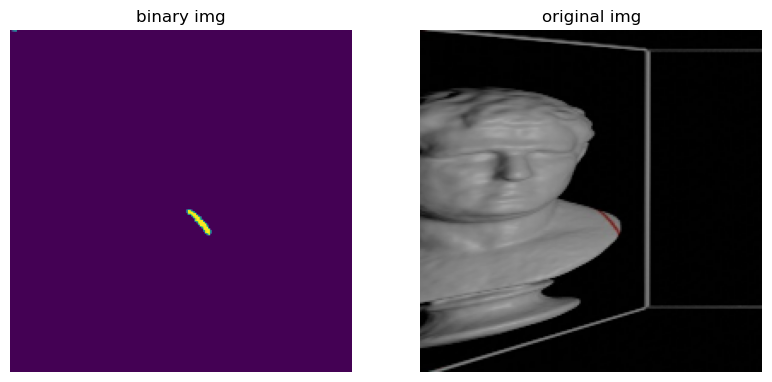

image: 52


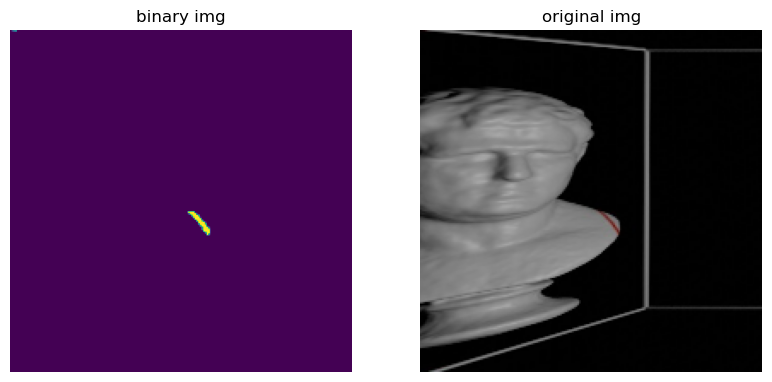

image: 53


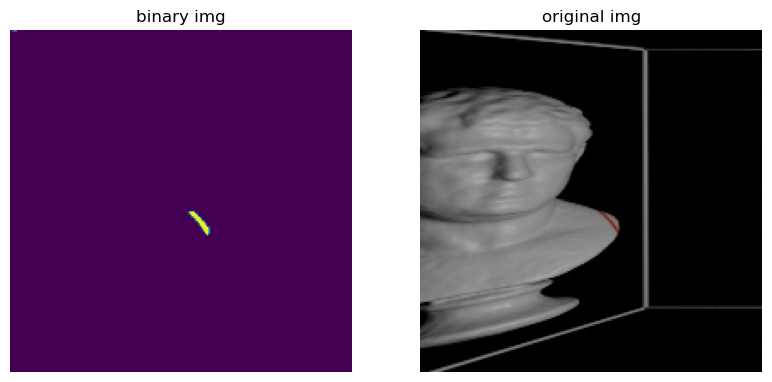

image: 54


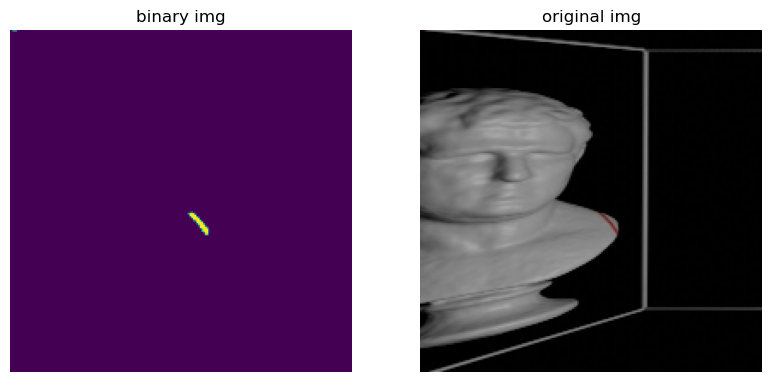

In [11]:
# plotting binary images vs original images after homography step
for x in range(55):
    fig = plt.figure(figsize=(15, 5))
    
    print('image:', x)
    fig.add_subplot(131)
    plt.title('binary img')
    plt.imshow(binary_img_homography[x])
    plt.axis('off')
    
    fig.add_subplot(132)
    plt.title('original img')
    plt.imshow(original_img_homography[x])
    plt.axis('off')
    
    plt.show()

In [12]:
# function to choose the first occurrence of a max value as single pixel per row
def choose_max_px(binary_image):
    
    filtered_image = np.empty_like(binary_image) 
    
    # iterate over the rows of the image
    for idx, row_array in enumerate(binary_image):
        data = row_array
        
        max_index = np.argmax(data) # find index of highest point
        
        zero_array = np.zeros(shape=(200,), dtype=np.uint8) 
        zero_array[max_index] = data[max_index]

        filtered_image[idx] = zero_array
        
    return filtered_image  

In [13]:
binary_img_homography[18][125]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,  40, 255, 255, 255, 255, 255,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [14]:
filtered_img_list = [choose_max_px(img) for img in binary_img_homography]
filtered_img_list[18][125]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

image: 0


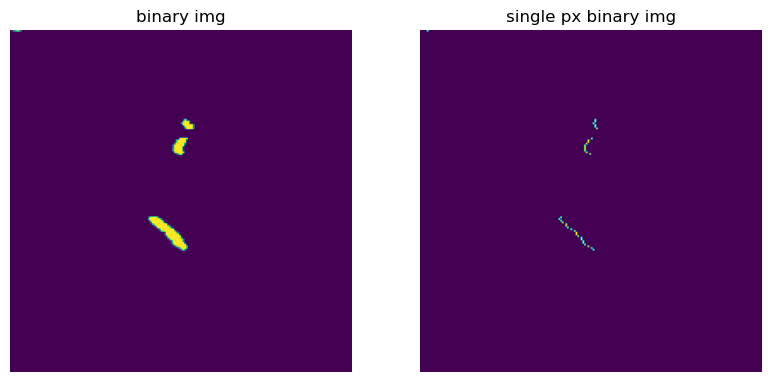

image: 1


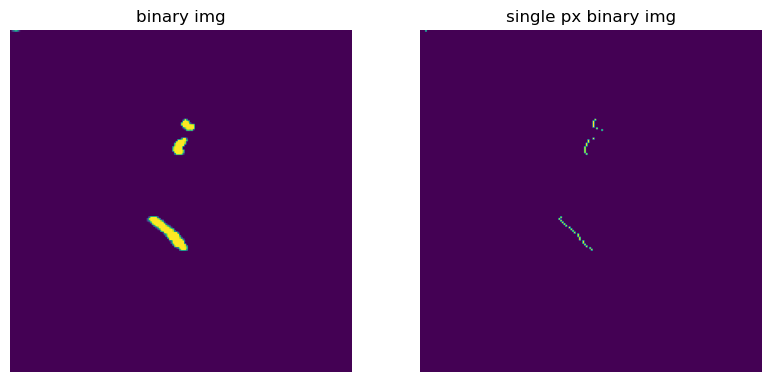

image: 2


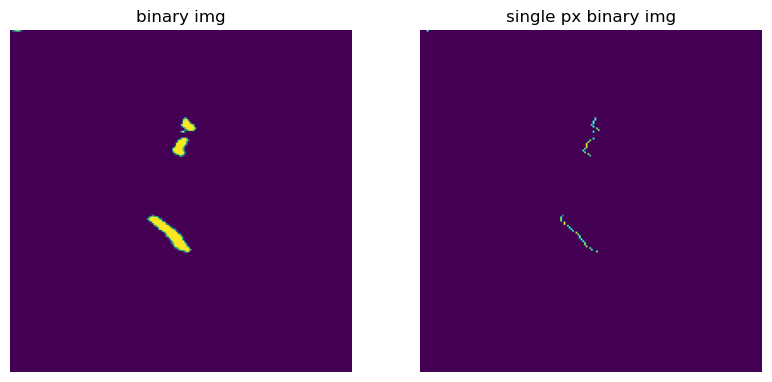

image: 3


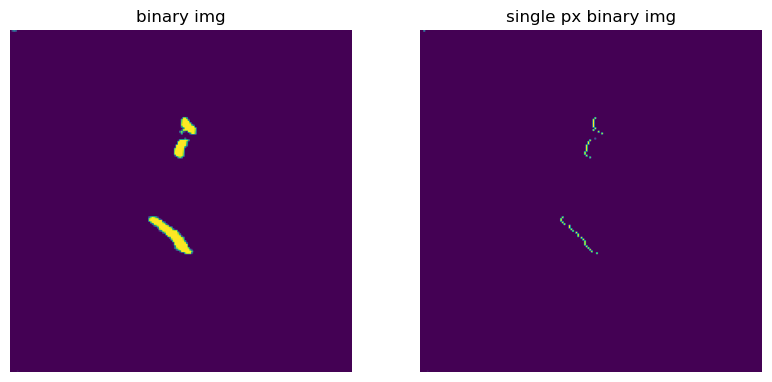

image: 4


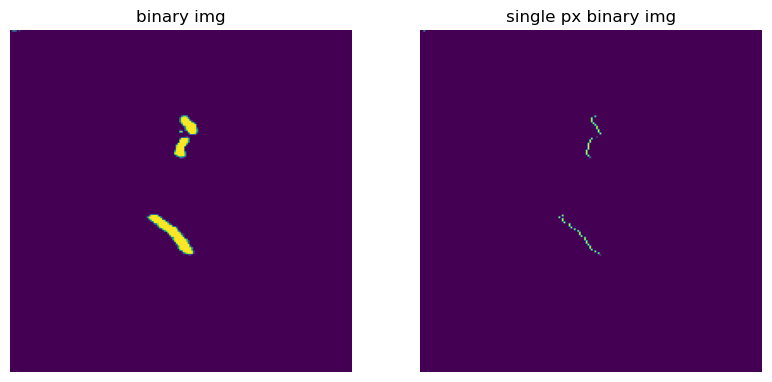

image: 5


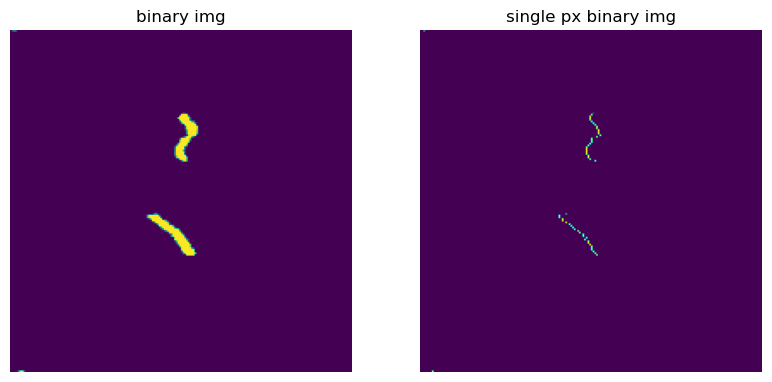

image: 6


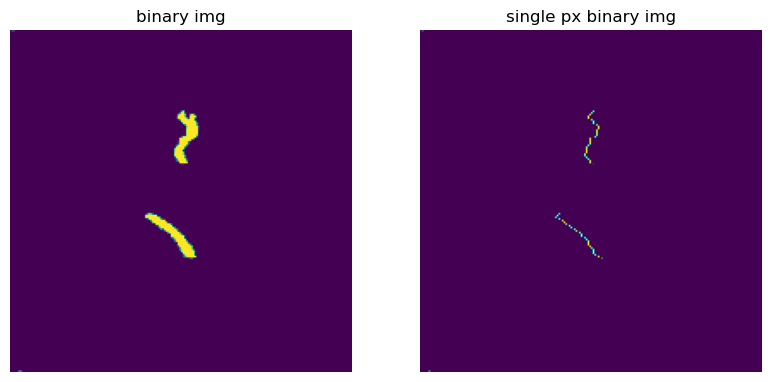

image: 7


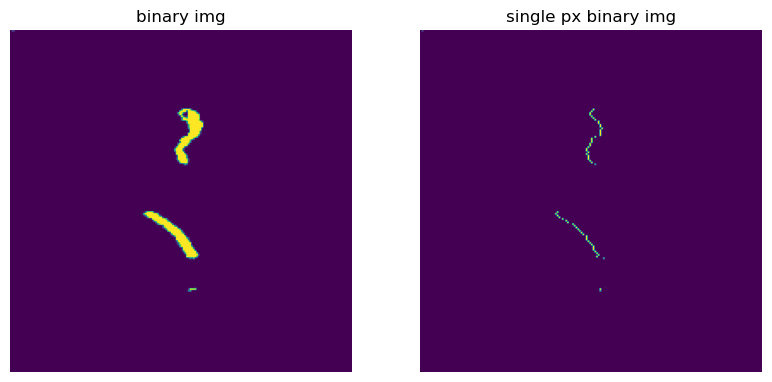

image: 8


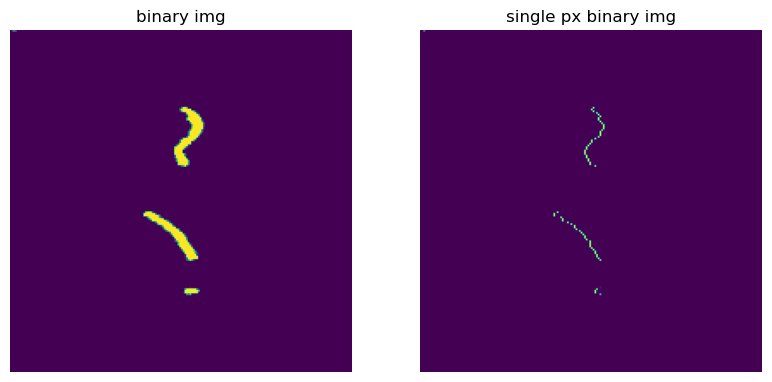

image: 9


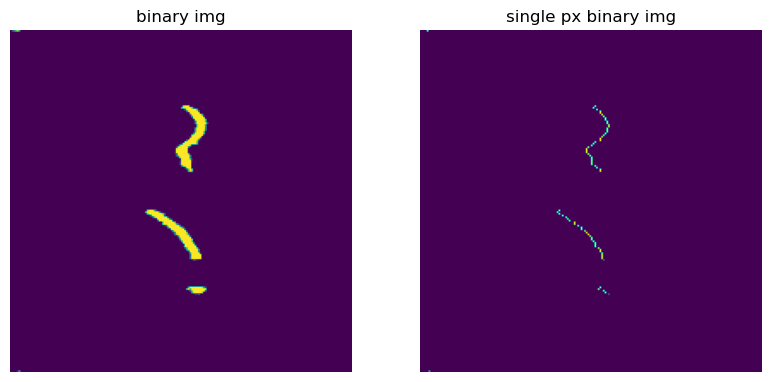

image: 10


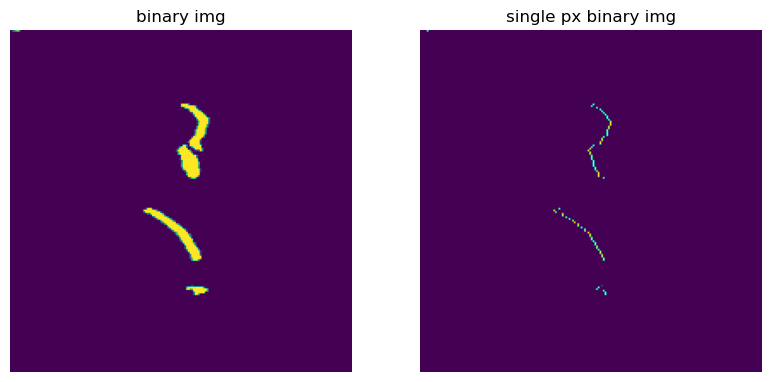

image: 11


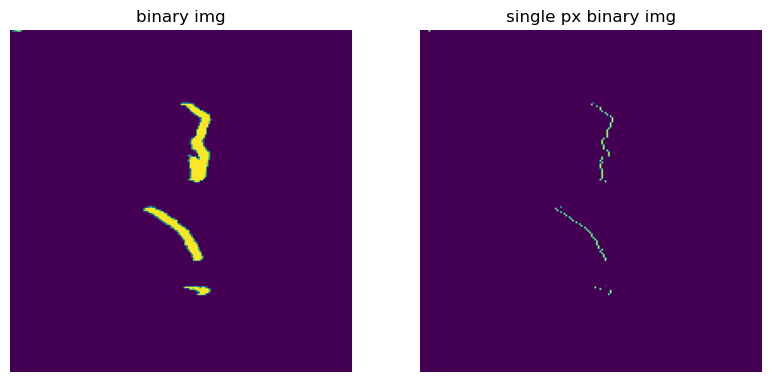

image: 12


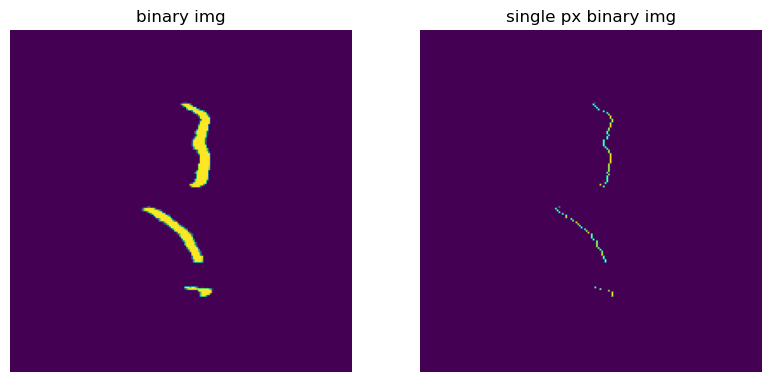

image: 13


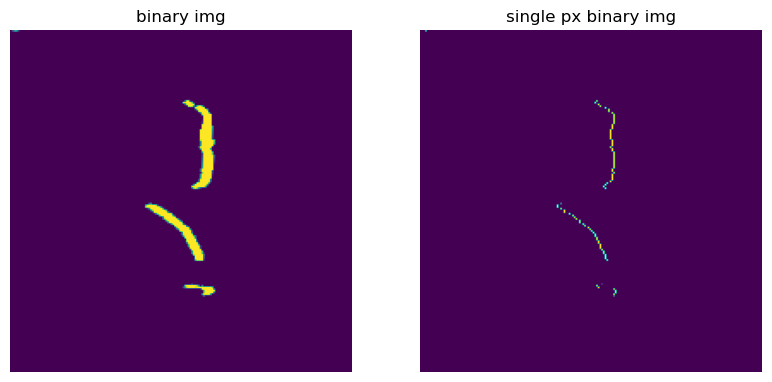

image: 14


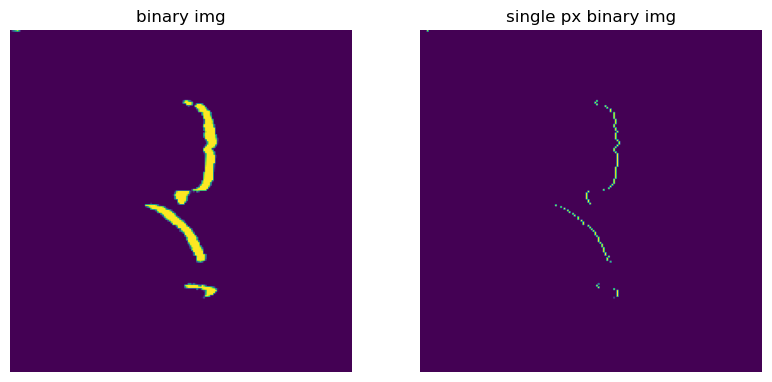

image: 15


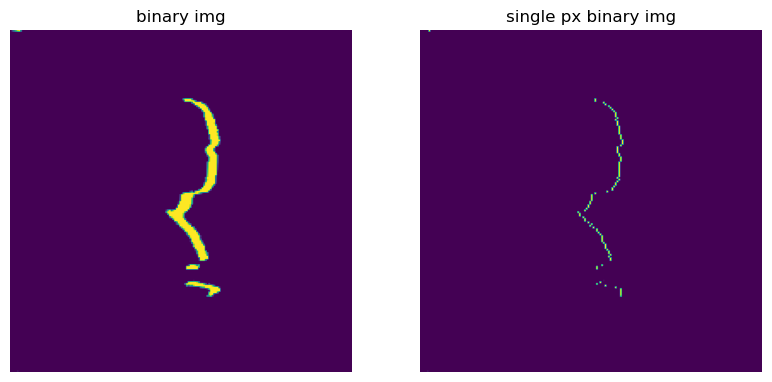

image: 16


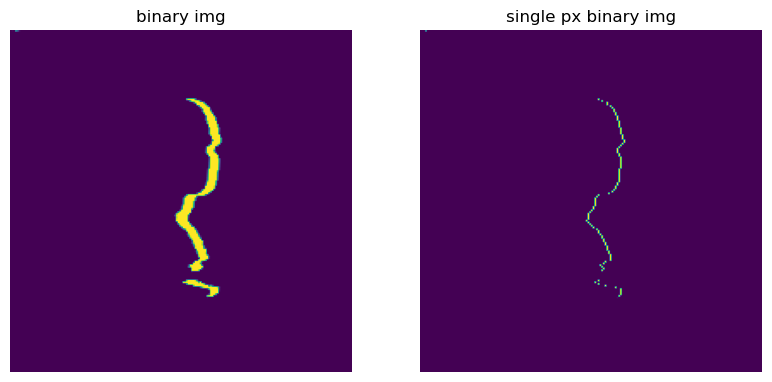

image: 17


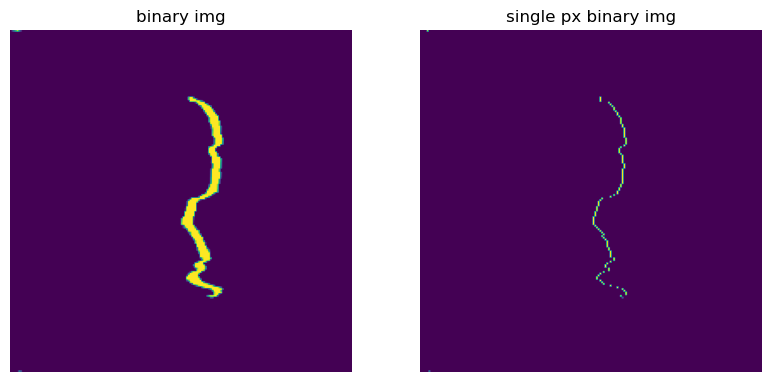

image: 18


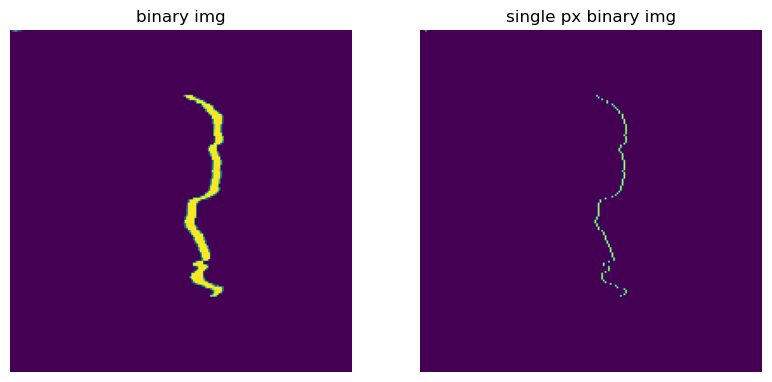

image: 19


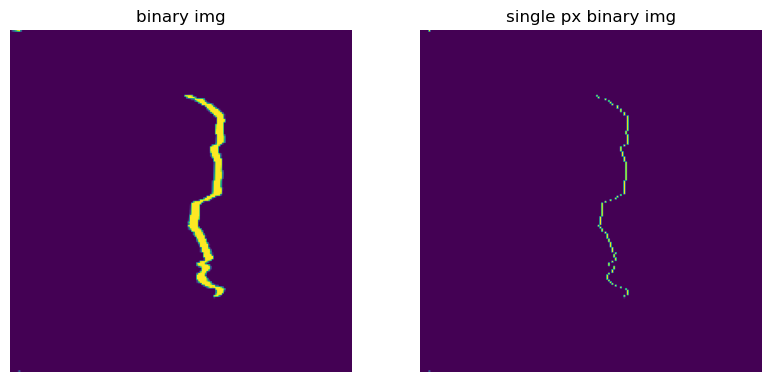

image: 20


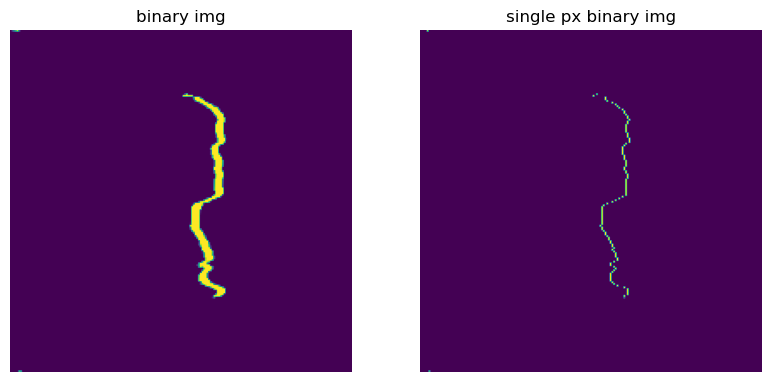

image: 21


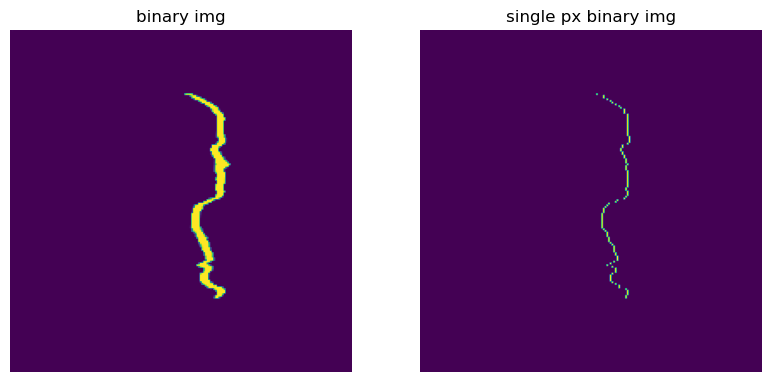

image: 22


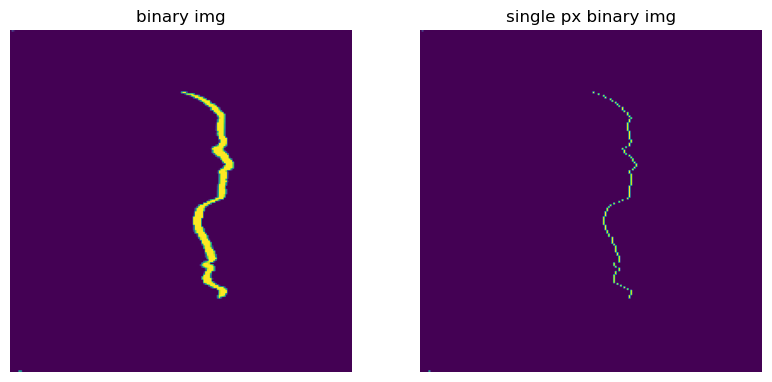

image: 23


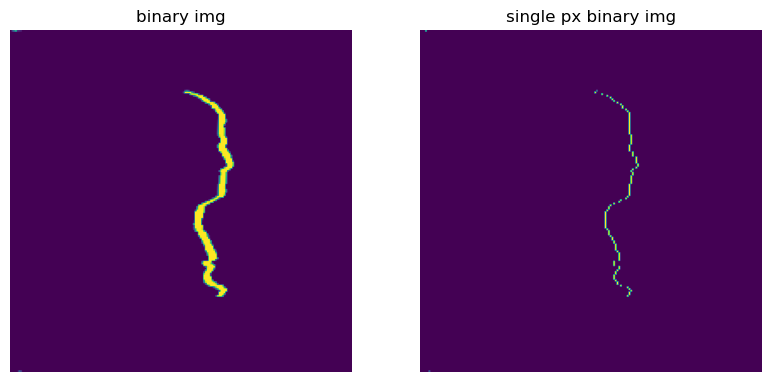

image: 24


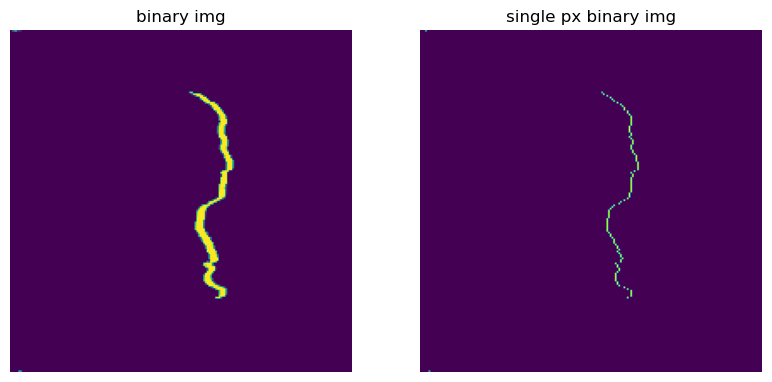

image: 25


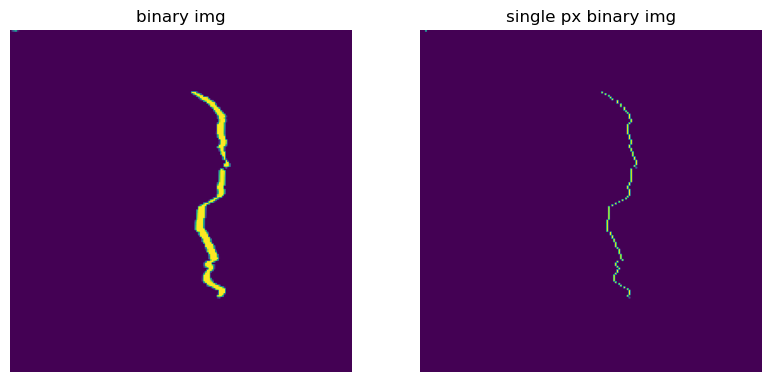

image: 26


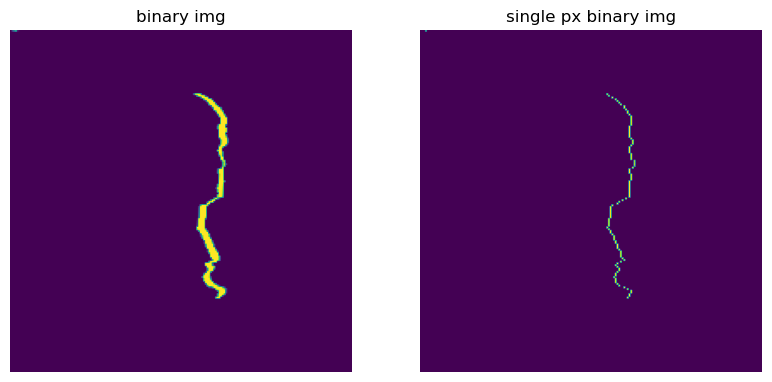

image: 27


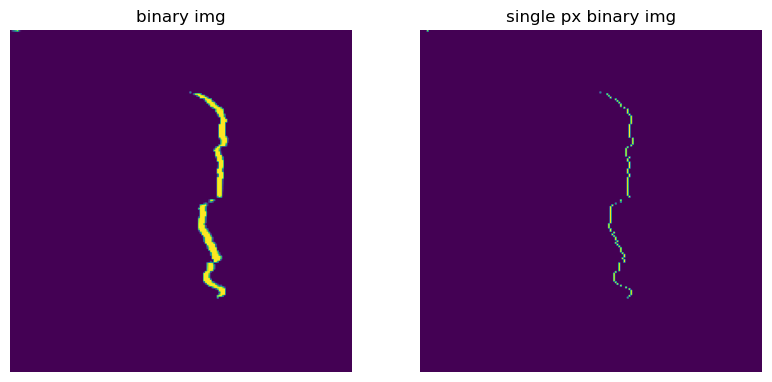

image: 28


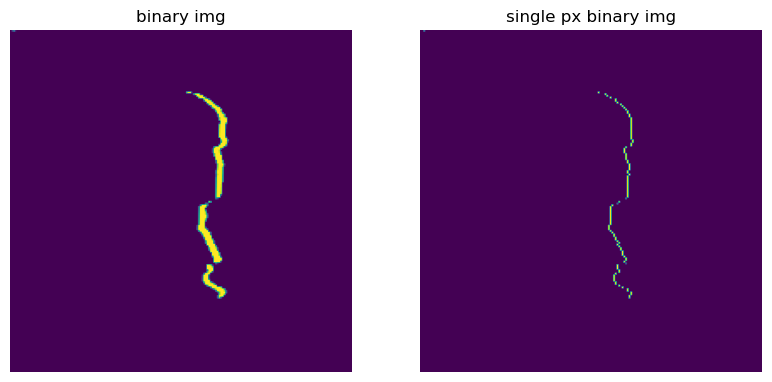

image: 29


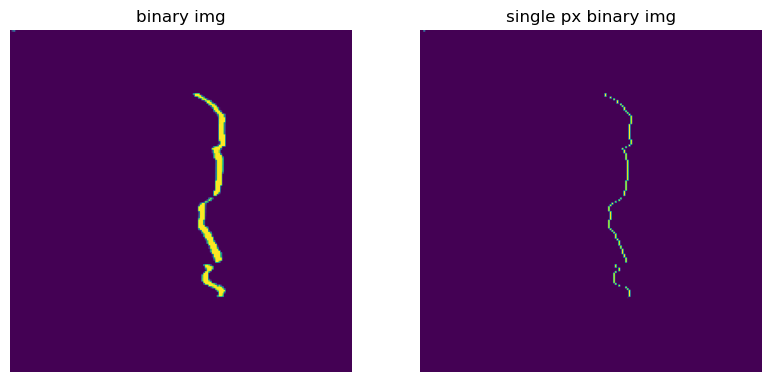

image: 30


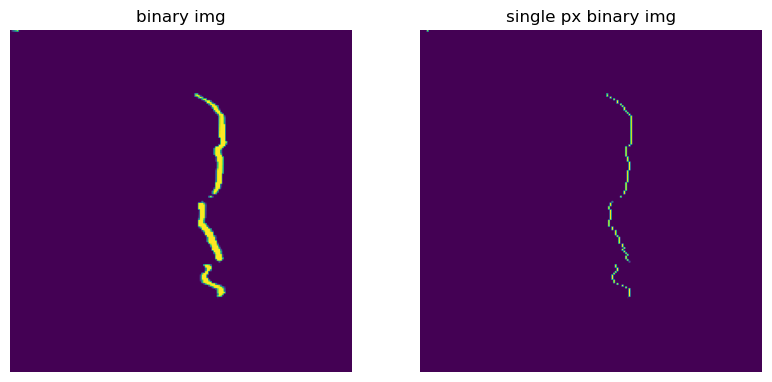

image: 31


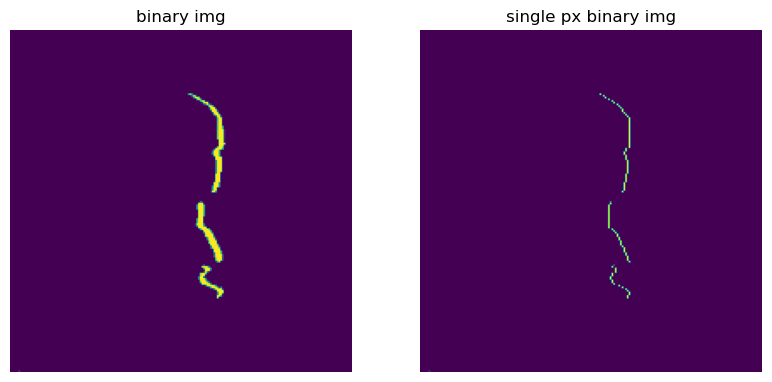

image: 32


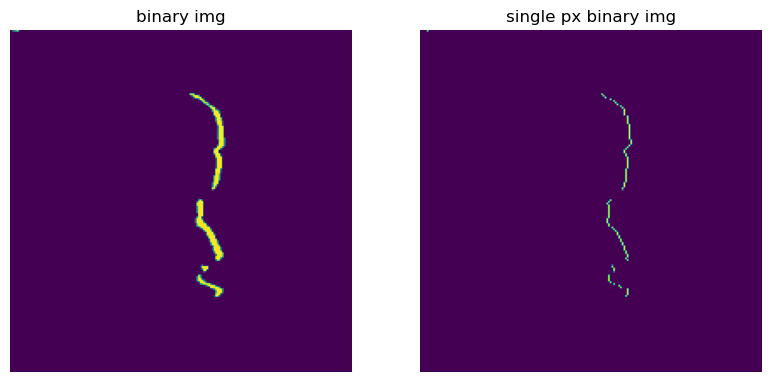

image: 33


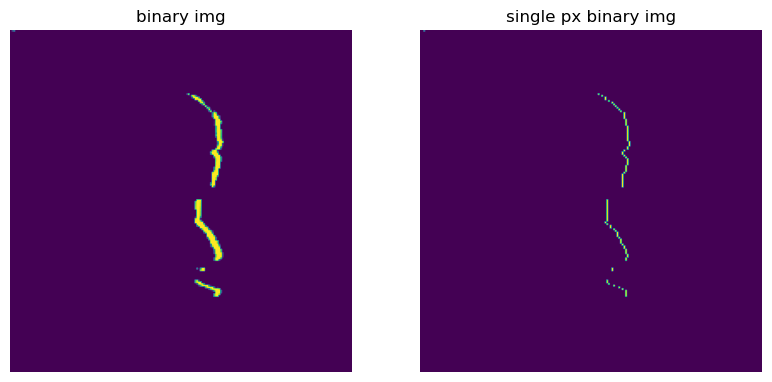

image: 34


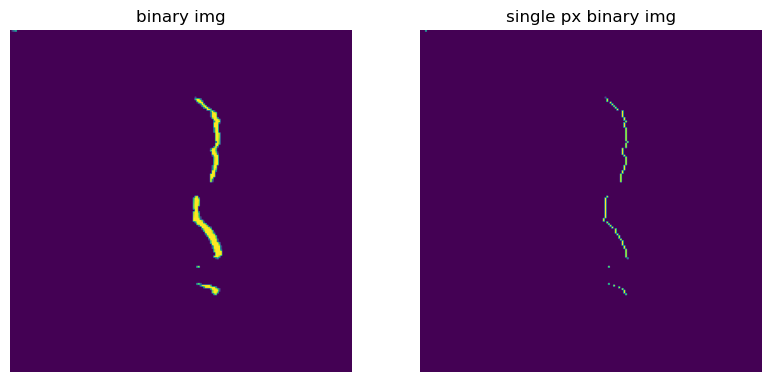

image: 35


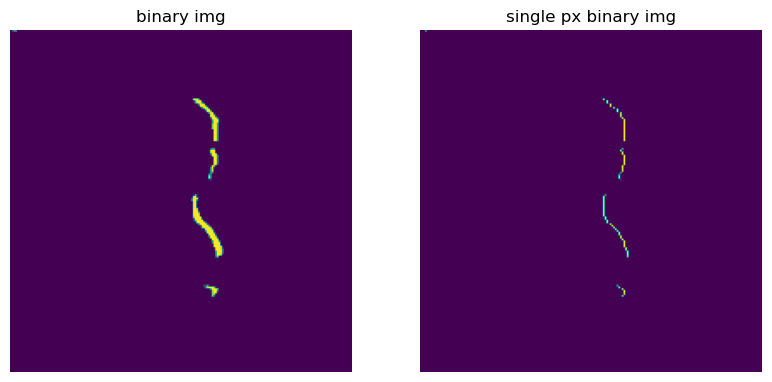

image: 36


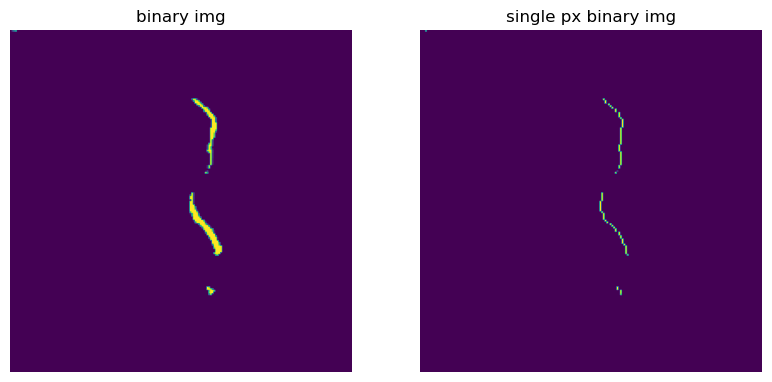

image: 37


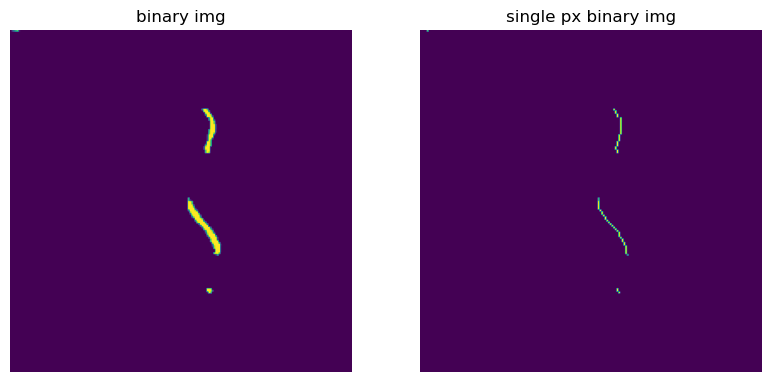

image: 38


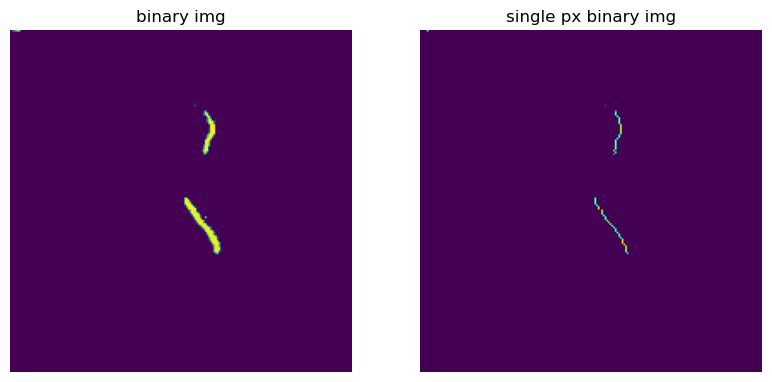

image: 39


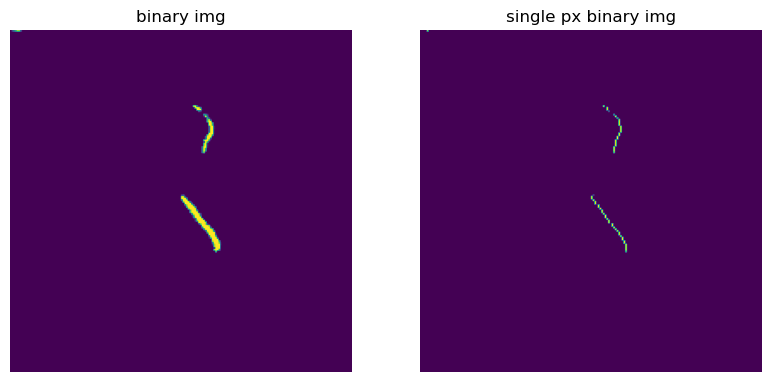

image: 40


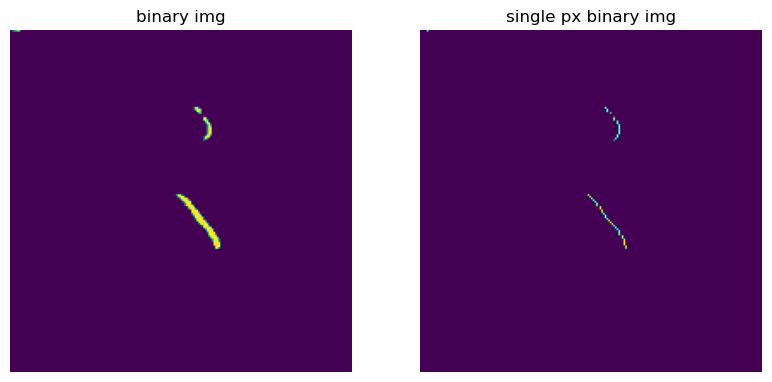

image: 41


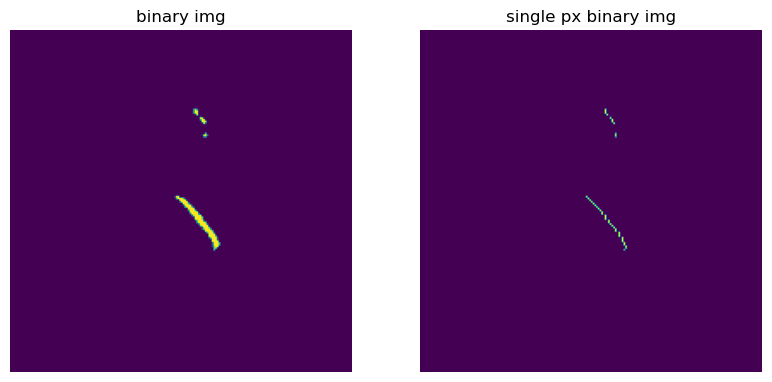

image: 42


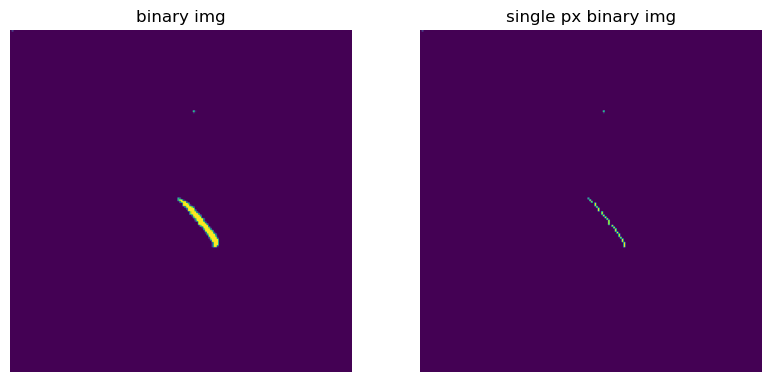

image: 43


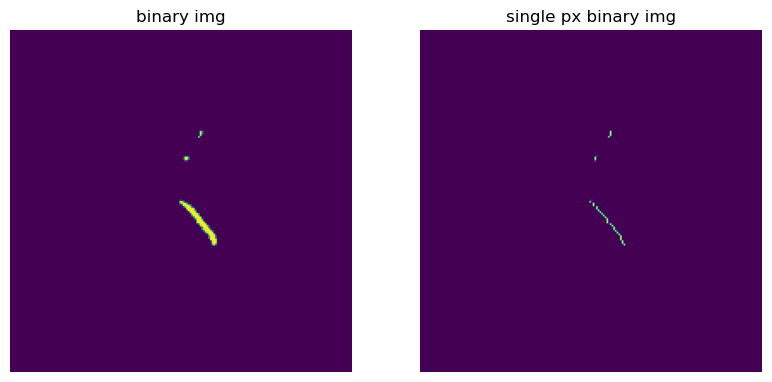

image: 44


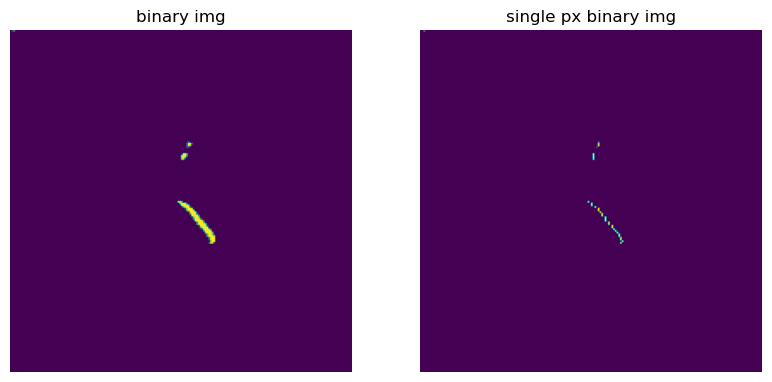

image: 45


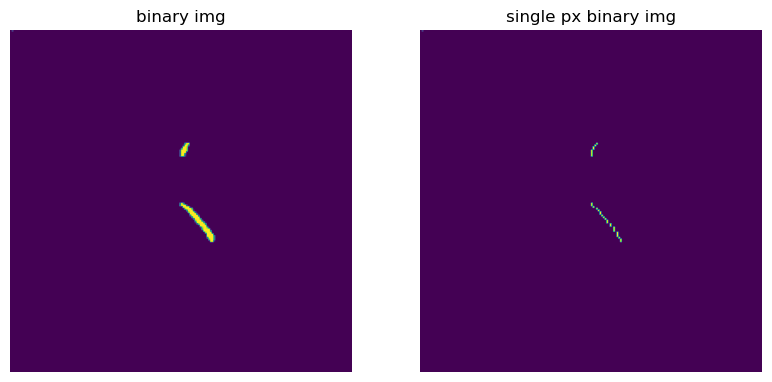

image: 46


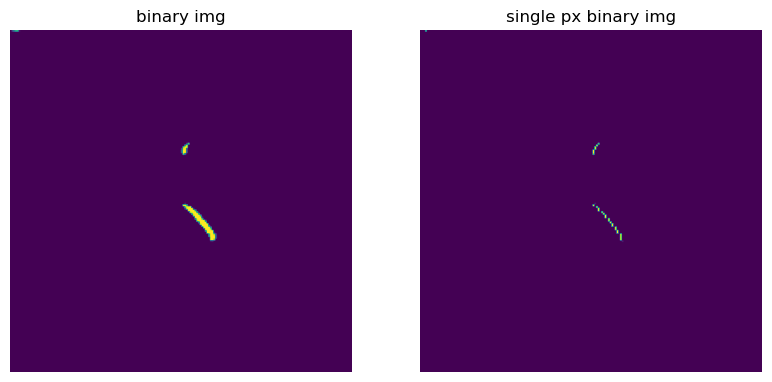

image: 47


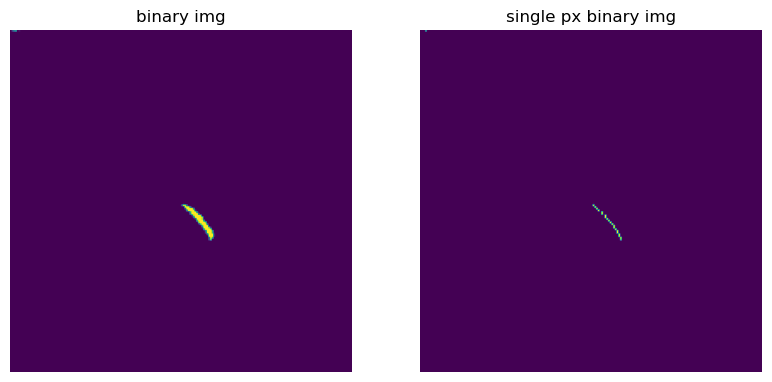

image: 48


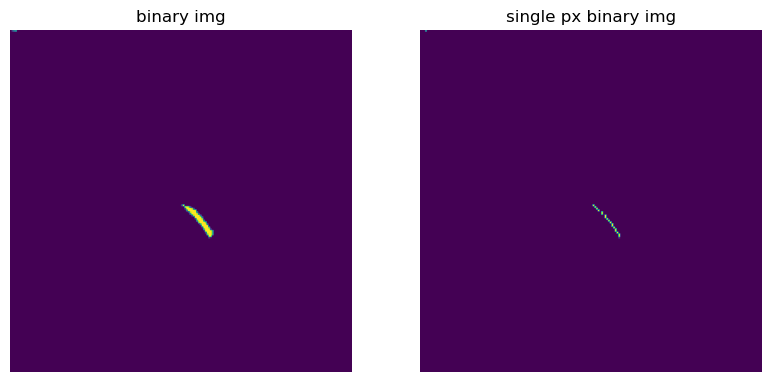

image: 49


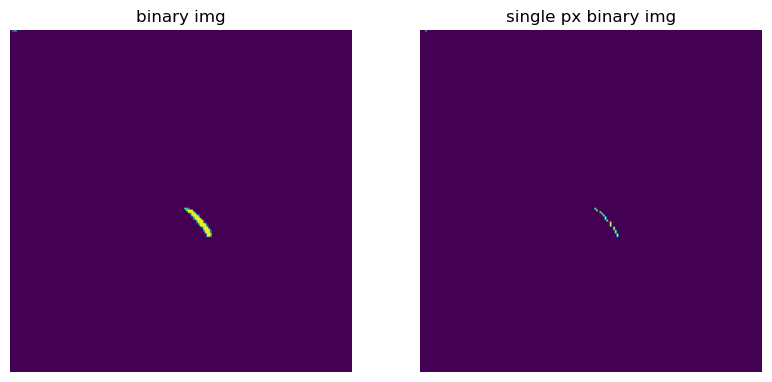

image: 50


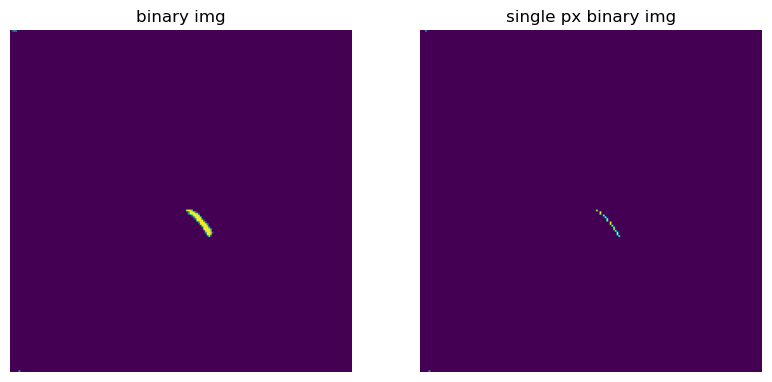

image: 51


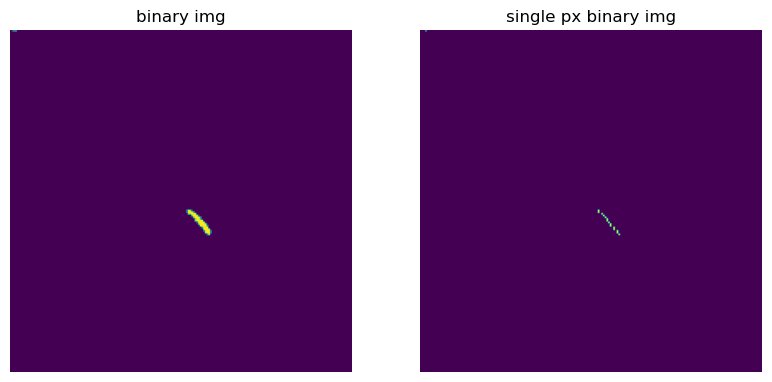

image: 52


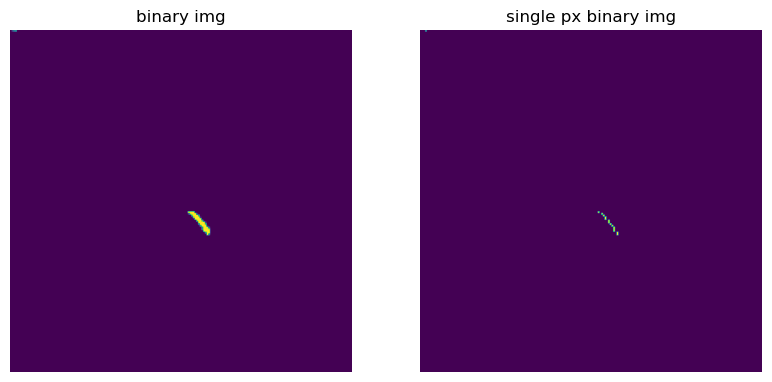

image: 53


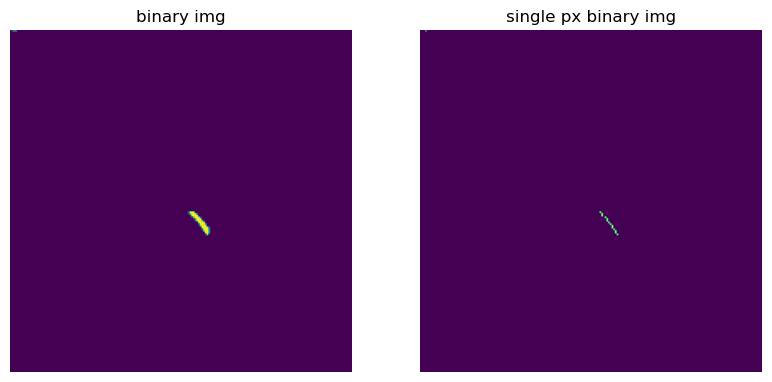

image: 54


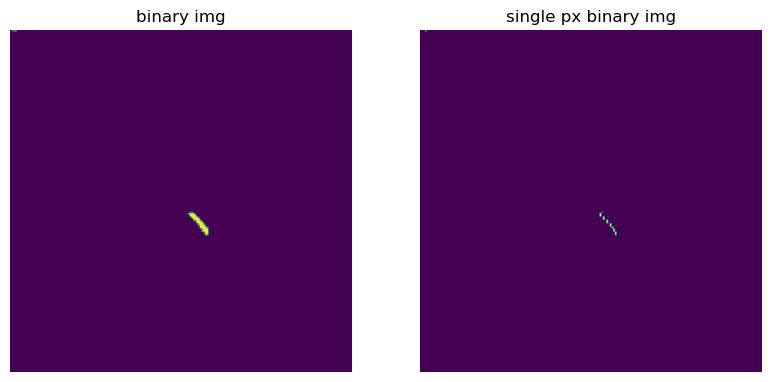

In [15]:
# plotting binary images vs single pixel binary images
for x in range(55):
    fig = plt.figure(figsize=(15, 5))
    
    print('image:', x)
    fig.add_subplot(131)
    plt.title('binary img')
    plt.imshow(binary_img_homography[x])
    plt.axis('off')
    
    fig.add_subplot(132)
    plt.title('single px binary img')
    plt.imshow(filtered_img_list[x])
    plt.axis('off')
    
    plt.show()

In [16]:
# function to mask over any value at the borders of the image, to eliminate
# pixels of the wireframe left
def mask_borders(binary_image):
    binary_image[:5, :] = 0   # first 5 rows
    binary_image[-5:, :] = 0  # last 5 rows
    binary_image[:, :5] = 0   # first 5 columns
    binary_image[:, -5:] = 0  # last 5 columns
    
    return binary_image

In [17]:
filtered_img_list[18][0]

array([  0,   0,   0, 175,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [18]:
masked_img_list = [mask_borders(img) for img in filtered_img_list]
masked_img_list[18][0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=uint8)

In [19]:
# function to calculate the xyz coordinates of each red shadow pattern
# to then write into a .xyz file
def calculate_xyz_coordinates(x_3d, binary_image):
    
    # row list: it knows which rows have red shadows
    red_px = np.sum(binary_image, axis=1) 
    red_px = red_px > 0
    
    last_value = 0
    xyz_list = []
    
    # get the xyz coordinates for 3d world by using the slices of a 2d image
    for idx in range(red_px.shape[0]):
        if red_px[idx] == 1: # True   
            y_2d = idx
            z_3d = 100 - y_2d
            
            x_2d = np.argmax(binary_image[idx])
            y_3d = 100 - x_2d
            
            xyz_list.append([x_3d, y_3d, z_3d])
            
    return xyz_list

In [20]:
xyz_coordinate_list = [calculate_xyz_coordinates(idx - 28, img) for idx, img  in enumerate(masked_img_list)]

In [21]:
# stack the coordinates of all images
xyz_file = []

for xyz in xyz_coordinate_list:
    xyz_file += xyz
    
print('amount of xyz points:', len(xyz_file))

amount of xyz points: 4046


In [23]:
array = np.array(xyz_file)

# define the filename
filename = "F11115117.xyz"

# save the array to the .xyz file
np.savetxt(filename, array, fmt='%d', delimiter='\t')

print(f"array saved to {filename}")

array saved to F11115117.xyz
